# tACS Bandit — Combined EEG Analysis PipelineThis notebook consolidates all EEG analysis for the tACS bandit study into a single pipeline with two primary functions:1. **Quality audit**: Verify stimulation delivery (active vs sham vs none) for every    run of every subject, flag protocol mismatches, and visualize 6 Hz power timecourses.2. **Theta reactivity**: Extract a robust individual-difference measure of task-related    theta (4–8 Hz) power from verified clean baseline runs, assess test–retest reliability,    and examine age associations.Additionally, the notebook performs **spectral parameterization** (ITF/IAF extraction) and **exploratory ERSP analysis** (epoch-locked theta, reward vs no-reward).## Key Methodological Notes- **Stimulation detection** uses cross-run adaptive classification (v5.2): each subject's   runs are compared against their own baseline distribution using median power and IQR.- **Theta reactivity** is computed on continuous EEG from verified clean runs only — runs   flagged by the quality audit are automatically excluded.- **Timestamp alignment** between EEG and behavioral computers uses a heuristic approach   (no hardware synchronization). Theta metrics are described as "task-related" rather than   "feedback-locked."- **EEG channels**: F4, P4, P3 (indices 4, 5, 6). Stimulation channels (F3, Fp1, FCz, FT7)   are blanked by NIC2 during recording.

---## 0. Setup and Configuration

In [3]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import signal, stats
from scipy.signal import butter, filtfilt, iirnotch, hilbert
from scipy.stats import pearsonr, spearmanr, ttest_ind
from pathlib import Path
from specparam import SpectralModel
from datetime import datetime

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='loadtxt: input contained no data')

# --- Plotly configuration ---
PLOTLY_TEMPLATE = 'plotly_white'
COLOR_BLUE = '#1565C0'
COLOR_GOLD = '#FFB300'
COLOR_GREEN = '#2E7D32'
COLOR_RED = '#C62828'
COLOR_GRAY = '#757575'

# --- Path configuration ---
REPO_ROOT = Path('..').resolve()
EEG_DIR = REPO_ROOT / 'data' / 'nic' / 'raw'
BEHAV_DIR = REPO_ROOT / 'data' / 'bandit'
OUTPUT_DIR = REPO_ROOT / 'derivatives' / 'eeg'
PLOT_DIR = OUTPUT_DIR / 'plots'
THETA_DIR = OUTPUT_DIR / 'feedback_theta'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
THETA_DIR.mkdir(parents=True, exist_ok=True)

# --- Subject tracker (single source of truth) ---
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B', 'earclip': False, 'notes': ''},
    '10998': {'counterbalance': 'B', 'earclip': False, 'notes': 'Missing Run 1; Run 6 was sham (experimenter error)'},
    '11773': {'counterbalance': 'B', 'earclip': False, 'notes': 'Runs 6-7 were sham (experimenter error)'},
    '10656': {'counterbalance': 'A', 'earclip': False, 'notes': ''},
    '10951': {'counterbalance': 'A', 'earclip': False, 'notes': 'Intermittent electrode artifact (loose connection); affects Runs 1, 6, 8 — Run 6 IQR=33 dB (extreme); Runs 1 and 8 misclassified as SHAM. EEG data unreliable; behavioral data OK.'},
    '10418': {'counterbalance': 'B', 'earclip': False, 'notes': ''},
    '10636': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '11318': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10369': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '10606': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '11628': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '11286': {'counterbalance': 'A', 'earclip': True, 'notes': ''},
    '10866': {'counterbalance': 'B', 'earclip': True, 'notes': ''},
    '11329': {'counterbalance': 'B', 'earclip': True, 'notes': ''}
}

# --- Run structure ---
RUN_CONDITIONS = {
    'A': {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
          5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'},
    'B': {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
          5: 'baseline', 6: 'active', 7: 'active', 8: 'post'},
}

# --- EEG constants ---
FS = 500
CH_LABELS = ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3', 'Ch8']
STIM_CH_IDX = [0, 1, 2, 3]
EEG_CH_IDX = [4, 5, 6]
EEG_CH_LABELS = ['F4', 'P4', 'P3']
TACS_FREQ = 6.0

# --- Frequency bands ---
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 50),
}
THETA_BAND = (4, 8)

# --- Epoch parameters (for ERSP) ---
EPOCH_PRE = 1.0
EPOCH_POST = 1.5
BASELINE_WIN = (-0.5, -0.1)

# --- Preprocessing parameters ---
HIGHPASS_FREQ = 0.5
ARTIFACT_THRESH_UV = 150

PREPROC_PARAMS = {
    'earclip': {
        'apply_avg_reref': False,
        'highpass_cutoff': 0.5,
        'lowpass_cutoff': 40.0,
        'notch_freq': 60.0,
        'artifact_threshold_uv': 150,
    },
    'no_earclip': {
        'apply_avg_reref': True,
        'highpass_cutoff': 0.5,
        'lowpass_cutoff': 40.0,
        'notch_freq': 60.0,
        'artifact_threshold_uv': 150,
    }
}

# --- Stimulation detection thresholds (reference only; v5.2 uses adaptive) ---
STIM_THRESHOLDS = {
    'earclip': {'active_middle_min_db': 88, 'active_sustained_diff_db': 5,
                'sham_early_min_db': 85, 'sham_early_late_diff_db': 10},
    'no_earclip': {'active_middle_min_db': 100, 'active_sustained_diff_db': 10,
                   'sham_early_min_db': 100, 'sham_early_late_diff_db': 15}
}

# --- ITF extraction parameters ---
ITF_PARAMS = {
    'r_squared_threshold': 0.70,
    'theta_range': (4, 8),
    'alpha_range': (8, 13),
    'specparam_settings': {
        'peak_width_limits': (0.5, 6),
        'max_n_peaks': 6,
        'min_peak_height': 0.05,
        'aperiodic_mode': 'fixed',
    }
}

print(f'Repository root: {REPO_ROOT}')
print(f'EEG directory: {EEG_DIR}')
print(f'Behavioral directory: {BEHAV_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'\nSubjects: {len(SUBJECT_INFO)}')
print(f'  Earclip: {[s for s, info in SUBJECT_INFO.items() if info["earclip"]]}')
print(f'  No-earclip: {[s for s, info in SUBJECT_INFO.items() if not info["earclip"]]}')

issues = [(s, info['notes']) for s, info in SUBJECT_INFO.items() if info['notes']]
if issues:
    print(f'\n⚠ Known issues:')
    for s, note in issues:
        print(f'  {s}: {note}')


Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
EEG directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/nic/raw
Behavioral directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit
Output directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg

Subjects: 14
  Earclip: ['10636', '11318', '10369', '10606', '11628', '11286', '10866', '11329']
  No-earclip: ['10886', '10998', '11773', '10656', '10951', '10418']

⚠ Known issues:
  10998: Missing Run 1; Run 6 was sham (experimenter error)
  11773: Runs 6-7 were sham (experimenter error)
  10951: Intermittent electrode artifact (loose connection); affects Runs 1, 6, 8 — Run 6 IQR=33 dB (extreme); Runs 1 and 8 misclassified as SHAM. EEG data unreliable; behavioral data OK.


---## 1. Utility Functions

In [5]:
# =============================================================================
# 1a. Plot Saving Utility
# =============================================================================

def save_plot(fig, name, subject_id=None, format='png'):
    date_str = datetime.now().strftime('%Y%m%d')
    if subject_id:
        filename = f'{name}_sub-{subject_id}_{date_str}.{format}'
    else:
        filename = f'{name}_{date_str}.{format}'
    filepath = PLOT_DIR / filename
    if format == 'png':
        fig.write_image(str(filepath), scale=2)
    elif format == 'html':
        fig.write_html(str(filepath))
    else:
        fig.write_image(str(filepath))
    print(f'Saved: {filepath}')
    return filepath


# =============================================================================
# 1b. EEG Data Loading (from EEG notebook — handles full 8-channel NIC2 files)
# =============================================================================

def load_nic2_run(easy_path, info_path=None, imp_path=None):
    """Load a single NIC2 recording (full 8 channels, nanovolts)."""
    raw = np.loadtxt(easy_path)
    eeg = raw[:, :8]
    triggers = raw[:, 11] if raw.shape[1] > 11 else np.zeros(len(raw))
    timestamps = raw[:, 12] if raw.shape[1] > 12 else np.arange(len(raw))

    info = {}
    if info_path and Path(info_path).exists():
        with open(info_path, 'r') as f:
            info_text = f.read()
        for line in info_text.split('\n'):
            if 'EEG sampling rate' in line and 'Samples' in line:
                info['fs'] = int(line.split(':')[1].strip().split()[0])
            if 'Step name' in line:
                info['step_name'] = line.split(':')[1].strip()
            if 'Atacs (uA)' in line:
                val = int(line.split(':')[1].strip())
                if val > 0:
                    info['has_active_stim'] = True

    fs = info.get('fs', FS)
    stim_mask = (eeg[:, 0] == -1)

    impedance = None
    if imp_path and Path(imp_path).exists():
        try:
            imp_raw = np.loadtxt(imp_path)
            if imp_raw.ndim == 2 and imp_raw.shape[0] > 0:
                impedance = {'values': imp_raw[:, :8], 'mean_per_channel': np.mean(imp_raw[:, :8], axis=0)}
        except Exception:
            pass

    return {
        'eeg': eeg, 'timestamps': timestamps, 'triggers': triggers,
        'fs': fs, 'stim_mask': stim_mask, 'impedance': impedance, 'info': info,
    }


def discover_runs(eeg_dir, subject_id):
    """Find all NIC2 files for a subject."""
    pattern = str(eeg_dir / f'*sub-{subject_id}_Run*')
    all_files = glob.glob(pattern + '.easy')

    runs = {}
    for easy_path in sorted(all_files):
        easy_path = Path(easy_path)
        fname = easy_path.stem
        try:
            run_str = fname.split('Run')[1].strip().split('_')[0].strip()
            run_num = int(run_str)
        except (IndexError, ValueError):
            continue

        info_path = easy_path.with_suffix('.info')
        imp_candidates = list(eeg_dir.glob(f'*sub-{subject_id}_Run*{run_num}_IMP.txt'))
        imp_path = imp_candidates[0] if imp_candidates else None

        file_size = easy_path.stat().st_size
        if run_num not in runs or file_size > runs[run_num]['size']:
            runs[run_num] = {
                'easy': easy_path, 'info': info_path if info_path.exists() else None,
                'imp': imp_path, 'size': file_size,
            }

    for run in runs.values():
        del run['size']
    return runs


# =============================================================================
# 1c. EEG Data Loading (theta-notebook style — µV, 3-channel, with time_sec)
# =============================================================================

def load_eeg_run(easy_path):
    """Load EEG for theta/ERSP analysis (3 EEG channels, microvolts)."""
    raw = np.loadtxt(easy_path)
    eeg = raw[:, EEG_CH_IDX] / 1000.0  # nV → µV
    timestamps_unix_ms = raw[:, 12]
    time_sec = (timestamps_unix_ms - timestamps_unix_ms[0]) / 1000.0
    return {
        'eeg': eeg, 'timestamps_unix_ms': timestamps_unix_ms,
        'time_sec': time_sec, 'fs': FS, 'duration_sec': time_sec[-1]
    }


def find_eeg_run(eeg_dir, subject_id, run_num):
    """Find the EEG .easy file for a given subject and run."""
    pattern = str(eeg_dir / f'*sub-{subject_id}_Run*{run_num}*.easy')
    files = glob.glob(pattern)
    matches = []
    for f in files:
        fname = os.path.basename(f)
        try:
            run_str = fname.split('Run')[1].strip().split('.')[0].strip()
            if int(run_str) == run_num:
                matches.append(f)
        except (IndexError, ValueError):
            continue
    if not matches:
        return None
    return max(matches, key=os.path.getsize)


# =============================================================================
# 1d. Behavioral Data Loading
# =============================================================================

def load_behavioral_run(csv_path):
    """Load behavioral data and compute feedback times."""
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=['rt']).copy()
    df['rt_sec'] = df['rt'] / 1000.0
    df['iti_sec'] = df['iti'] / 1000.0
    FEEDBACK_DURATION = 1.0
    df['feedback_time'] = df['timestamp'] - FEEDBACK_DURATION - df['iti_sec']
    first_feedback = df['feedback_time'].iloc[0]
    df['feedback_time_relative'] = df['feedback_time'] - first_feedback
    df.attrs['first_feedback_in_run'] = first_feedback
    return df


def get_latest_run_file(subject_dir, run_num):
    """Find the latest behavioral CSV for a given run."""
    pattern = str(subject_dir / f'*run-{run_num:02d}*.csv')
    files = glob.glob(pattern)
    if not files:
        return None
    return max(files, key=os.path.getmtime)


def get_subject_age(subject_id):
    """Extract age from behavioral CSV."""
    behav_dir = BEHAV_DIR / f'sub-{subject_id}'
    behav_path = get_latest_run_file(behav_dir, 1)
    if behav_path is None:
        behav_path = get_latest_run_file(behav_dir, 5)
    if behav_path is None:
        return None
    df = pd.read_csv(behav_path)
    if 'age' in df.columns:
        return df['age'].iloc[0]
    return None


print('Utility functions ready.')


Utility functions ready.


---## 2. Preprocessing

In [7]:
# =============================================================================
# 2a. Filters
# =============================================================================

def apply_filters(eeg_data, fs=FS, highpass=0.5, lowpass=40.0, notch=60.0):
    """Apply bandpass and notch filters (for stim detection pipeline)."""
    nyq = fs / 2
    b, a = butter(4, [highpass / nyq, lowpass / nyq], btype='band')
    if eeg_data.ndim == 1:
        filtered = filtfilt(b, a, eeg_data.astype(float))
    else:
        filtered = np.zeros_like(eeg_data, dtype=float)
        for ch in range(eeg_data.shape[1]):
            filtered[:, ch] = filtfilt(b, a, eeg_data[:, ch].astype(float))
    if notch is not None:
        b_notch, a_notch = iirnotch(notch, Q=30, fs=fs)
        if filtered.ndim == 1:
            filtered = filtfilt(b_notch, a_notch, filtered)
        else:
            for ch in range(filtered.shape[1]):
                filtered[:, ch] = filtfilt(b_notch, a_notch, filtered[:, ch])
    return filtered


def highpass_filter(data, cutoff=HIGHPASS_FREQ, fs=FS, order=4):
    """Apply zero-phase Butterworth high-pass filter."""
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype='high')
    if data.ndim == 1:
        return filtfilt(b, a, data)
    else:
        return np.column_stack([filtfilt(b, a, data[:, i]) for i in range(data.shape[1])])


def bandpass_filter(data, band, fs=FS, order=4):
    """Apply zero-phase Butterworth bandpass filter."""
    nyq = fs / 2
    low, high = band
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    if data.ndim == 1:
        return filtfilt(b, a, data)
    else:
        return np.column_stack([filtfilt(b, a, data[:, i]) for i in range(data.shape[1])])


# =============================================================================
# 2b. Re-referencing and Artifact Rejection
# =============================================================================

def avg_rereference(eeg, ch_indices=EEG_CH_IDX):
    """Average re-reference across specified channels."""
    subset = eeg[:, ch_indices].astype(float)
    avg = np.mean(subset, axis=1, keepdims=True)
    return subset - avg


def reject_artifacts(eeg_data, fs=FS, threshold_uv=150, highpass=0.5,
                     detect_pops=True, pop_threshold_uv=500):
    """Artifact rejection on filtered data (for stim detection pipeline)."""
    eeg_uv = eeg_data / 1000
    nyq = fs / 2
    b, a = butter(2, highpass / nyq, btype='high')
    eeg_filtered = filtfilt(b, a, eeg_uv.astype(float))
    amp_clean = np.abs(eeg_filtered) < threshold_uv
    if detect_pops:
        diff = np.abs(np.diff(eeg_uv))
        pop_mask = np.concatenate([[False], diff > pop_threshold_uv])
        extend_samples = int(0.05 * fs)
        for idx in np.where(pop_mask)[0]:
            start = max(0, idx - extend_samples)
            end = min(len(pop_mask), idx + extend_samples)
            pop_mask[start:end] = True
        pop_clean = ~pop_mask
    else:
        pop_clean = np.ones(len(eeg_uv), dtype=bool)
    clean_mask = amp_clean & pop_clean
    pct_rejected = 100 * (1 - clean_mask.mean())
    return clean_mask, pct_rejected, {
        'pct_amplitude': 100 * (1 - amp_clean.mean()),
        'pct_pops': 100 * (1 - pop_clean.mean()) if detect_pops else 0,
        'pct_total': pct_rejected,
    }


def preprocess_eeg_stim(eeg_raw, has_earclip, fs=FS):
    """Full preprocessing for stim detection / ITF pipeline."""
    params = PREPROC_PARAMS['earclip' if has_earclip else 'no_earclip']
    eeg_subset = eeg_raw[:, EEG_CH_IDX].astype(float)
    if params['apply_avg_reref']:
        eeg_reref = avg_rereference(eeg_raw)
    else:
        eeg_reref = eeg_subset
    eeg_filtered = apply_filters(eeg_reref, fs=fs, highpass=params['highpass_cutoff'],
                                  lowpass=params['lowpass_cutoff'], notch=params['notch_freq'])
    clean_mask, pct_rejected, rejection_info = reject_artifacts(
        eeg_filtered[:, 0], fs=fs, threshold_uv=params['artifact_threshold_uv'],
        highpass=params['highpass_cutoff'])
    return eeg_filtered, clean_mask, {
        'has_earclip': has_earclip, 'params': params, 'rejection': rejection_info,
        'n_samples_clean': np.sum(clean_mask), 'n_samples_total': len(clean_mask),
    }


def preprocess_eeg_theta(eeg_data, has_earclip=False):
    """Preprocessing for theta/ERSP pipeline (µV input)."""
    eeg = eeg_data['eeg'].copy()
    eeg = highpass_filter(eeg, cutoff=HIGHPASS_FREQ)
    if not has_earclip:
        avg = np.mean(eeg, axis=1, keepdims=True)
        eeg = eeg - avg
    artifact_mask = np.any(np.abs(eeg) > ARTIFACT_THRESH_UV, axis=1)
    result = eeg_data.copy()
    result['eeg'] = eeg
    result['artifact_mask'] = artifact_mask
    result['artifact_pct'] = 100 * np.mean(artifact_mask)
    return result


print('Preprocessing functions ready.')


Preprocessing functions ready.


---## 3. Stimulation Detection (v5.2)Cross-run adaptive classification using median power and IQR. Each subject's runs are compared against their own baseline distribution.

In [9]:
def compute_6hz_timecourse(eeg_data, fs=FS):
    """Compute time-resolved 6 Hz power."""
    f, t_spec, Sxx = signal.spectrogram(
        signal.detrend(eeg_data), fs=fs,
        nperseg=1000, noverlap=750, scaling='density'
    )
    
    six_hz_mask = (f >= 5.5) & (f <= 6.5)
    power_db = 10 * np.log10(np.mean(Sxx[six_hz_mask, :], axis=0) + 1e-30)
    
    return t_spec, power_db


def compute_window_powers(eeg_data, fs=FS):
    """Compute 6 Hz power in early, middle, and late windows."""
    t_spec, power_db = compute_6hz_timecourse(eeg_data, fs)
    
    if len(t_spec) == 0:
        return {'error': 'No spectrogram'}
    
    duration = t_spec[-1]
    
    early_mask = t_spec <= 45
    middle_mask = (t_spec >= 60) & (t_spec <= min(300, duration - 45))
    late_mask = t_spec >= (duration - 45)
    
    return {
        'early_db': np.mean(power_db[early_mask]) if np.any(early_mask) else np.nan,
        'middle_db': np.mean(power_db[middle_mask]) if np.any(middle_mask) else np.nan,
        'late_db': np.mean(power_db[late_mask]) if np.any(late_mask) else np.nan,
        'duration_s': duration,
        't_spec': t_spec,
        'power_db': power_db,
    }


def classify_stimulation_single(eeg_data, has_earclip, fs=FS):
    """
    Per-run feature extraction for stimulation classification.
    
    Returns a feature dict used by classify_all_runs() for cross-run
    comparison. Can also provide a standalone classification, but the
    cross-run approach in classify_all_runs() is preferred.
    
    v5.2 — WHAT WE LEARNED FROM PREVIOUS ATTEMPTS:
    
    Attempt 1 (absolute thresholds): Failed because earclip subjects have
    lower overall power; active runs at ~100 dB fell below the 90 dB
    threshold.
    
    Attempt 2 (relative step, fixed windows): Failed because the middle
    window (60-300s) includes pre-stim baseline segments from the NIC2
    protocol, diluting the mean/median.
    
    Attempt 3 (percentile-based plateau detection): Failed because active
    runs have a COMPRESSED power distribution (small p85-p15 spread)
    while baseline runs have WIDER natural variance. The "step" metric
    was larger for baseline runs than for active runs — exactly inverted.
    
    KEY INSIGHT: Active stimulation at 6 Hz produces a constant-amplitude
    artifact that dominates the spectrogram, making the 6 Hz power
    timecourse both HIGHER (elevated median) and FLATTER (low IQR/std).
    Baseline EEG has lower median power with much wider fluctuations.
    Sham has a brief high-power ramp artifact in the first ~30-45s that
    then disappears.
    
    The reliable features are:
    - median_db: overall power level
    - iqr_db: interquartile range (flatness measure)
    - early_db: mean power in first 45s (high for sham ramp)
    - late_db: mean power in last 45s (low for sham)
    """
    t_spec, power_db = compute_6hz_timecourse(eeg_data, fs)
    
    if len(t_spec) == 0:
        return 'NONE', {'error': 'No spectrogram'}
    
    duration = t_spec[-1]
    
    # Overall distribution features
    median_db = np.median(power_db)
    iqr_db = np.percentile(power_db, 75) - np.percentile(power_db, 25)
    std_db = np.std(power_db)
    p10 = np.percentile(power_db, 10)
    p90 = np.percentile(power_db, 90)
    
    # Window features
    early_mask = t_spec <= 45
    middle_mask = (t_spec >= 60) & (t_spec <= min(300, duration - 45))
    late_mask = t_spec >= (duration - 45)
    
    early_db = np.mean(power_db[early_mask]) if np.any(early_mask) else np.nan
    middle_db = np.mean(power_db[middle_mask]) if np.any(middle_mask) else np.nan
    late_db = np.mean(power_db[late_mask]) if np.any(late_mask) else np.nan
    
    features = {
        'median_db': median_db,
        'iqr_db': iqr_db,
        'std_db': std_db,
        'p10': p10,
        'p90': p90,
        'early_db': early_db,
        'middle_db': middle_db,
        'late_db': late_db,
        'duration_s': duration,
        't_spec': t_spec,
        'power_db': power_db,
        'has_earclip': has_earclip,
    }
    
    return features


def classify_all_runs(run_features):
    """
    Classify all runs for a subject using cross-run comparison.
    
    This is the primary classification function. It takes the feature
    dicts from classify_stimulation_single() for all runs and classifies
    each by comparing against the subject's own baseline distribution.
    
    Logic:
    1. Identify "likely baseline" runs: those with the highest IQR (most
       variable = no sustained artifact). Take the top 3-4 runs by IQR
       as the baseline reference pool.
    2. Compute baseline median power from this pool.
    3. ACTIVE: median power elevated above baseline median by >=
       active_elevation_db AND low IQR (below iqr_threshold).
    4. SHAM: early_db elevated above baseline median by >=
       sham_ramp_elevation_db AND early-to-late drop >= sham_decay_db.
    5. NONE: everything else.
    
    Parameters
    ----------
    run_features : dict
        {run_num: features_dict} from classify_stimulation_single()
    
    Returns
    -------
    classifications : dict
        {run_num: {'classification': str, ...features + diagnostics}}
    """
    if not run_features:
        return {}
    
    # Sort runs by IQR (descending) — high-IQR runs are likely unstimulated
    runs_by_iqr = sorted(run_features.items(), 
                         key=lambda x: x[1].get('iqr_db', 0), reverse=True)
    
    # Use top half of runs (by IQR) as baseline reference, minimum 3
    n_baseline_ref = max(3, len(runs_by_iqr) // 2)
    baseline_pool = runs_by_iqr[:n_baseline_ref]
    
    baseline_median = np.median([f['median_db'] for _, f in baseline_pool])
    baseline_iqr = np.median([f['iqr_db'] for _, f in baseline_pool])
    
    # Thresholds
    active_elevation_db = 5      # median must exceed baseline by this much
    iqr_ratio_threshold = 0.75   # IQR must be less than this fraction of baseline IQR
    active_elevation_override = 20  # if elevation >= this, classify ACTIVE regardless of IQR
    sham_ramp_elevation_db = 10  # early window must exceed baseline median
    sham_decay_db = 5            # early must exceed late by this much
    
    classifications = {}
    
    for run_num, features in run_features.items():
        median_db = features['median_db']
        iqr_db = features['iqr_db']
        early_db = features['early_db']
        late_db = features['late_db']
        
        elevation = median_db - baseline_median
        iqr_ratio = iqr_db / baseline_iqr if baseline_iqr > 0 else 1.0
        early_elevation = early_db - baseline_median
        early_late_drop = early_db - late_db
        
        # ACTIVE: elevated + flat, OR massively elevated (override)
        if (elevation >= active_elevation_db and iqr_ratio <= iqr_ratio_threshold) or            elevation >= active_elevation_override:
            classification = 'ACTIVE'
        # SHAM: early ramp artifact that decays
        elif early_elevation >= sham_ramp_elevation_db and early_late_drop >= sham_decay_db:
            classification = 'SHAM'
        else:
            classification = 'NONE'
        
        classifications[run_num] = {
            **features,
            'classification': classification,
            'elevation': elevation,
            'iqr_ratio': iqr_ratio,
            'baseline_median': baseline_median,
            'baseline_iqr': baseline_iqr,
            'early_elevation': early_elevation,
            'early_late_drop': early_late_drop,
        }
    
    return classifications


# Backward-compatible wrapper: still usable for single-run contexts
# (e.g., the diagnostic plot). Uses simple heuristics without cross-run info.
def classify_stimulation(eeg_data, has_earclip, fs=FS):
    """
    Single-run classification (backward-compatible wrapper).
    
    For production use, prefer classify_all_runs() which uses cross-run
    comparison. This wrapper applies simple heuristics for contexts where
    only one run is available (e.g., diagnostic plots).
    """
    features = classify_stimulation_single(eeg_data, has_earclip, fs)
    
    if isinstance(features, tuple):
        return features  # Error case
    
    # Simple heuristic for single-run context:
    # Use absolute thresholds as fallback (less reliable than cross-run)
    median_db = features['median_db']
    iqr_db = features['iqr_db']
    early_db = features['early_db']
    late_db = features['late_db']
    
    # Active: high median + low variance
    if has_earclip:
        if median_db >= 95 and iqr_db < 3:
            classification = 'ACTIVE'
        elif early_db >= 95 and (early_db - late_db) >= 5:
            classification = 'SHAM'
        else:
            classification = 'NONE'
    else:
        if median_db >= 110 and iqr_db < 5:
            classification = 'ACTIVE'
        elif early_db >= 100 and (early_db - late_db) >= 10:
            classification = 'SHAM'
        else:
            classification = 'NONE'
    
    features['classification'] = classification
    return classification, features


print('Stimulation detection ready (v5.2: cross-run adaptive classification).')

Stimulation detection ready (v5.2: cross-run adaptive classification).


---## 4. Spectral Parameterization (ITF/IAF)

In [11]:
def compute_psd(eeg_data, fs=FS, nperseg=2048):
    """
    Compute PSD using Welch's method.
    
    v5: Added better handling of edge cases.
    """
    # Ensure we have valid data
    if len(eeg_data) < 256:
        return None, None
    
    # Adjust nperseg if needed
    if len(eeg_data) < nperseg:
        nperseg = min(len(eeg_data), 1024)
        if nperseg < 256:
            nperseg = 256
    
    # Detrend and compute PSD
    try:
        data = signal.detrend(eeg_data.astype(float))
        freqs, psd = signal.welch(data, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
        
        # Check for invalid values
        if np.any(np.isnan(psd)) or np.any(np.isinf(psd)):
            return None, None
        
        return freqs, psd
    except Exception as e:
        print(f'PSD computation error: {e}')
        return None, None


def fit_specparam(freqs, psd, freq_range=(1, 40)):
    """
    Fit specparam model.
    
    v5: Takes linear PSD (not log), handles conversion internally.
    """
    settings = ITF_PARAMS['specparam_settings']
    
    # Ensure PSD is positive before log transform
    psd_clean = np.maximum(psd, 1e-30)
    
    # Convert to log power for specparam
    # Note: specparam expects log10(power), not 10*log10(power)
    psd_log = np.log10(psd_clean)
    
    if np.any(np.isnan(psd_log)) or np.any(np.isinf(psd_log)):
        return None
    
    sm = SpectralModel(
        peak_width_limits=settings['peak_width_limits'],
        max_n_peaks=settings['max_n_peaks'],
        min_peak_height=settings['min_peak_height'],
        aperiodic_mode=settings['aperiodic_mode'],
        verbose=False,
    )
    
    try:
        sm.fit(freqs, psd_log, freq_range)
        return sm
    except Exception as e:
        return None


def extract_peaks(model, theta_range=(4, 8), alpha_range=(8, 13)):
    """
    Extract all peaks and identify theta/alpha peaks.
    
    v5: Returns more detailed peak information.
    """
    result = {
        'all_peaks': None,
        'theta_peak': None,
        'alpha_peak': None,
        'itf': None,
        'iaf': None,  # Individual Alpha Frequency
        'has_theta': False,
        'has_alpha': False,
    }
    
    if model is None:
        return result
    
    try:
        peaks = model.results.params.periodic.params
    except Exception:
        return result
    
    if peaks is None or (hasattr(peaks, '__len__') and len(peaks) == 0):
        return result
    
    # Ensure 2D
    if peaks.ndim == 1:
        peaks = peaks.reshape(1, -1)
    
    result['all_peaks'] = peaks
    
    # Find theta peaks
    theta_mask = (peaks[:, 0] >= theta_range[0]) & (peaks[:, 0] <= theta_range[1])
    if np.any(theta_mask):
        theta_peaks = peaks[theta_mask]
        best_theta = theta_peaks[np.argmax(theta_peaks[:, 1])]
        result['theta_peak'] = best_theta
        result['itf'] = best_theta[0]
        result['has_theta'] = True
    
    # Find alpha peaks
    alpha_mask = (peaks[:, 0] >= alpha_range[0]) & (peaks[:, 0] <= alpha_range[1])
    if np.any(alpha_mask):
        alpha_peaks = peaks[alpha_mask]
        best_alpha = alpha_peaks[np.argmax(alpha_peaks[:, 1])]
        result['alpha_peak'] = best_alpha
        result['iaf'] = best_alpha[0]
        result['has_alpha'] = True
    
    return result


def get_model_components(model):
    """
    Extract all components from fitted model for plotting.
    
    v5: Fixed to properly extract all model components.
    """
    if model is None:
        return None
    
    try:
        freqs = model.data.freqs
        power_spectrum = model.data.power_spectrum
        modeled_spectrum = model.results.model.modeled_spectrum
        
        # Aperiodic parameters and fit
        ap_params = model.results.params.aperiodic.params
        offset, exponent = ap_params[0], ap_params[1]
        aperiodic_fit = offset - exponent * np.log10(freqs)
        
        # R-squared
        r_squared = model.results.metrics.results.get('gof_rsquared', None)
        
        # Peaks
        peaks = model.results.params.periodic.params
        if peaks is not None and hasattr(peaks, '__len__') and len(peaks) > 0:
            if peaks.ndim == 1:
                peaks = peaks.reshape(1, -1)
        else:
            peaks = np.array([]).reshape(0, 3)
        
        return {
            'freqs': freqs,
            'power_spectrum': power_spectrum,
            'modeled_spectrum': modeled_spectrum,
            'aperiodic_fit': aperiodic_fit,
            'offset': offset,
            'exponent': exponent,
            'r_squared': r_squared,
            'peaks': peaks,
        }
    except Exception as e:
        print(f'Error extracting model components: {e}')
        return None


print('Spectral parameterization ready.')

Spectral parameterization ready.


---## 5. Quality Audit — Batch ProcessingRun stimulation detection, preprocessing, and spectral parameterization across all subjects. This produces the audit output used to gate downstream analyses.

In [14]:
def process_subject_multichannel(subject_id, eeg_dir=EEG_DIR, verbose=True):
    """
    Process one subject with full multi-channel analysis.
    
    v5: Analyzes all 3 EEG channels (F4, P4, P3) with equal priority.
    """
    sub_info = SUBJECT_INFO[subject_id]
    cb_order = sub_info['counterbalance']
    has_earclip = sub_info['earclip']
    condition_map = RUN_CONDITIONS[cb_order]
    
    run_files = discover_runs(eeg_dir, subject_id)
    
    if len(run_files) == 0:
        return {'subject_id': subject_id, 'error': 'No runs found'}
    
    results = {
        'subject_id': subject_id,
        'counterbalance': cb_order,
        'has_earclip': has_earclip,
        'notes': sub_info.get('notes', ''),
        'n_runs': len(run_files),
        'runs': {},
        'protocol_mismatches': [],
        'specparam_results': [],  # All channel results for diagnostics
    }
    
    # Initialize ITF storage for each channel
    for ch in EEG_CH_LABELS:
        results[f'itf_estimates_{ch}'] = []
        results[f'iaf_estimates_{ch}'] = []
    
    # --- Pass 1: Load all runs, extract features, preprocess ---
    loaded_runs = {}
    run_features = {}
    preproc_results = {}
    
    for run_num in sorted(run_files.keys()):
        files = run_files[run_num]
        expected_condition = condition_map.get(run_num, 'unknown')
        
        try:
            nic2 = load_nic2_run(files['easy'], files['info'], files['imp'])
        except Exception as e:
            results['runs'][run_num] = {'error': str(e)}
            if verbose:
                print(f'  Run {run_num} ({expected_condition})... ERROR: {e}')
            continue
        
        loaded_runs[run_num] = nic2
        
        # Extract stim features (no classification yet)
        features = classify_stimulation_single(
            nic2['eeg'][:, EEG_CH_IDX[0]], has_earclip, nic2['fs']
        )
        if not isinstance(features, tuple):  # not an error
            run_features[run_num] = features
        
        # Preprocess
        eeg_filtered, clean_mask, preproc_info = preprocess_eeg_stim(
            nic2['eeg'], has_earclip, nic2['fs']
        )
        preproc_results[run_num] = (eeg_filtered, clean_mask, preproc_info)
    
    # --- Pass 2: Cross-run classification ---
    stim_classifications = classify_all_runs(run_features)
    
    # --- Pass 3: Assemble results with protocol checks ---
    for run_num in sorted(loaded_runs.keys()):
        expected_condition = condition_map.get(run_num, 'unknown')
        
        if verbose:
            print(f'  Run {run_num} ({expected_condition})...', end=' ')
        
        nic2 = loaded_runs[run_num]
        stim_info = stim_classifications.get(run_num, {})
        stim_class = stim_info.get('classification', 'NONE')
        eeg_filtered, clean_mask, preproc_info = preproc_results[run_num]
        
        # Protocol check — flag mismatches in both directions
        protocol_ok = True
        if expected_condition == 'active' and stim_class != 'ACTIVE':
            protocol_ok = False
            results['protocol_mismatches'].append(run_num)
        elif expected_condition == 'sham' and stim_class not in ('SHAM', 'NONE'):
            protocol_ok = False
            results['protocol_mismatches'].append(run_num)
        
        run_result = {
            'condition': expected_condition,
            'stim_detected': stim_class,
            'protocol_ok': protocol_ok,
            'duration_s': stim_info.get('duration_s', 0),
            'pct_rejected': preproc_info['rejection']['pct_total'],
            'n_clean_samples': preproc_info['n_samples_clean'],
            'early_db': stim_info.get('early_db'),
            'middle_db': stim_info.get('middle_db'),
            'late_db': stim_info.get('late_db'),
            'median_db': stim_info.get('median_db'),
            'iqr_db': stim_info.get('iqr_db'),
            'elevation': stim_info.get('elevation'),
            'iqr_ratio': stim_info.get('iqr_ratio'),
            'baseline_median': stim_info.get('baseline_median'),
            'baseline_iqr': stim_info.get('baseline_iqr'),
        }
        
        # Process baseline and post runs for ITF
        if expected_condition in ['baseline', 'post'] and stim_class != 'ACTIVE':
            eeg_clean = eeg_filtered[clean_mask]
            
            if len(eeg_clean) >= 512:
                # Process ALL channels
                for ch_idx, ch_label in enumerate(EEG_CH_LABELS):
                    freqs, psd = compute_psd(eeg_clean[:, ch_idx])
                    
                    if freqs is not None and psd is not None:
                        model = fit_specparam(freqs, psd)
                        peaks = extract_peaks(model)
                        components = get_model_components(model)
                        
                        r_squared = components['r_squared'] if components else None
                        
                        # Store in run results
                        run_result[f'{ch_label}_itf'] = peaks['itf']
                        run_result[f'{ch_label}_iaf'] = peaks['iaf']
                        run_result[f'{ch_label}_has_theta'] = peaks['has_theta']
                        run_result[f'{ch_label}_has_alpha'] = peaks['has_alpha']
                        run_result[f'{ch_label}_r2'] = r_squared
                        run_result[f'{ch_label}_n_peaks'] = len(peaks['all_peaks']) if peaks['all_peaks'] is not None else 0
                        
                        # Store for aggregation
                        if peaks['has_theta'] and r_squared and r_squared >= ITF_PARAMS['r_squared_threshold']:
                            results[f'itf_estimates_{ch_label}'].append(peaks['itf'])
                        
                        if peaks['has_alpha'] and r_squared and r_squared >= ITF_PARAMS['r_squared_threshold']:
                            results[f'iaf_estimates_{ch_label}'].append(peaks['iaf'])
                        
                        # Store detailed results for diagnostics
                        results['specparam_results'].append({
                            'run': run_num,
                            'condition': expected_condition,
                            'channel': ch_label,
                            'r_squared': r_squared,
                            'itf': peaks['itf'],
                            'iaf': peaks['iaf'],
                            'has_theta': peaks['has_theta'],
                            'has_alpha': peaks['has_alpha'],
                            'all_peaks': peaks['all_peaks'],
                            'model': model,
                            'components': components,
                            'freqs': freqs,
                            'psd': psd,
                        })
        
        results['runs'][run_num] = run_result
        
        if verbose:
            status = '✓' if protocol_ok else '⚠'
            elev = stim_info.get('elevation', 0)
            iqr_r = stim_info.get('iqr_ratio', 0)
            med = stim_info.get('median_db', 0)
            iqr = stim_info.get('iqr_db', 0)
            print(f'{status} {stim_class}, {run_result["pct_rejected"]:.1f}% rej  '
                  f'[med={med:.1f}, iqr={iqr:.1f}, elev={elev:+.1f}, iqr_r={iqr_r:.2f}]')
    
    # Aggregate ITF/IAF across runs for each channel
    for ch_label in EEG_CH_LABELS:
        itf_estimates = results[f'itf_estimates_{ch_label}']
        iaf_estimates = results[f'iaf_estimates_{ch_label}']
        
        if len(itf_estimates) > 0:
            results[f'itf_{ch_label}'] = np.median(itf_estimates)
            results[f'itf_{ch_label}_n'] = len(itf_estimates)
        else:
            results[f'itf_{ch_label}'] = None
            results[f'itf_{ch_label}_n'] = 0
        
        if len(iaf_estimates) > 0:
            results[f'iaf_{ch_label}'] = np.median(iaf_estimates)
            results[f'iaf_{ch_label}_n'] = len(iaf_estimates)
        else:
            results[f'iaf_{ch_label}'] = None
            results[f'iaf_{ch_label}_n'] = 0
    
    # Compute "best" ITF across channels
    all_itf = []
    for ch in EEG_CH_LABELS:
        if results[f'itf_{ch}'] is not None:
            all_itf.append((ch, results[f'itf_{ch}'], results[f'itf_{ch}_n']))
    
    if all_itf:
        # Pick channel with most estimates, or highest ITF if tied
        all_itf.sort(key=lambda x: (-x[2], -x[1]))
        results['best_itf_channel'] = all_itf[0][0]
        results['best_itf'] = all_itf[0][1]
    else:
        results['best_itf_channel'] = None
        results['best_itf'] = None
    
    return results


print('Multi-channel pipeline ready.')

Multi-channel pipeline ready.


### 5a. Run Batch Processing

In [21]:
all_results = []

print('Processing all subjects (multi-channel)...')
print('=' * 70)

for subject_id in SUBJECT_INFO:
    print(f'\nsub-{subject_id}')
    result = process_subject_multichannel(subject_id, eeg_dir=EEG_DIR, verbose=True)
    all_results.append(result)

print('\n' + '=' * 70)
print('Batch processing complete.')


Processing all subjects (multi-channel)...

sub-10886
  Run 1 (baseline)... ✓ NONE, 0.2% rej  [med=89.1, iqr=3.7, elev=-0.2, iqr_r=0.87]
  Run 2 (sham)... ✓ SHAM, 15.0% rej  [med=89.6, iqr=4.8, elev=+0.2, iqr_r=1.12]
  Run 3 (sham)... ✓ SHAM, 14.5% rej  [med=89.6, iqr=4.8, elev=+0.2, iqr_r=1.12]
  Run 4 (post)... ✓ NONE, 0.0% rej  [med=89.0, iqr=3.8, elev=-0.3, iqr_r=0.88]
  Run 5 (baseline)... ✓ NONE, 0.5% rej  [med=88.6, iqr=3.7, elev=-0.7, iqr_r=0.86]
  Run 6 (active)... ✓ ACTIVE, 84.5% rej  [med=151.7, iqr=0.1, elev=+62.3, iqr_r=0.02]
  Run 7 (active)... ✓ ACTIVE, 84.2% rej  [med=151.4, iqr=0.2, elev=+62.1, iqr_r=0.04]
  Run 8 (post)... ✓ NONE, 0.0% rej  [med=88.8, iqr=3.4, elev=-0.5, iqr_r=0.81]

sub-10998
  Run 2 (sham)... ✓ SHAM, 15.6% rej  [med=89.3, iqr=5.0, elev=+0.1, iqr_r=1.14]
  Run 3 (sham)... ✓ SHAM, 15.2% rej  [med=89.1, iqr=4.4, elev=-0.0, iqr_r=1.00]
  Run 4 (post)... ✓ NONE, 0.5% rej  [med=88.8, iqr=3.4, elev=-0.4, iqr_r=0.78]
  Run 5 (baseline)... ✓ NONE, 0.2% rej  

/opt/anaconda3/lib/python3.12/site-packages/specparam/data/data.py:300: RuntimeWarning: invalid value encountered in log10
  powers = np.log10(powers)


  Run 1 (baseline)... ✓ NONE, 0.8% rej  [med=70.3, iqr=4.2, elev=+1.3, iqr_r=0.73]
  Run 2 (sham)... ✓ SHAM, 18.1% rej  [med=69.2, iqr=5.9, elev=+0.2, iqr_r=1.04]
  Run 3 (sham)... ✓ SHAM, 19.0% rej  [med=69.1, iqr=7.9, elev=+0.0, iqr_r=1.38]
  Run 4 (post)... ✓ NONE, 1.4% rej  [med=67.0, iqr=5.3, elev=-2.0, iqr_r=0.94]
  Run 5 (baseline)... ✓ NONE, 0.5% rej  [med=66.7, iqr=5.4, elev=-2.4, iqr_r=0.94]
  Run 6 (active)... ✓ ACTIVE, 99.9% rej  [med=149.1, iqr=0.1, elev=+80.1, iqr_r=0.02]
  Run 7 (active)... ✓ ACTIVE, 99.8% rej  [med=148.5, iqr=0.2, elev=+79.5, iqr_r=0.04]
  Run 8 (post)... ✓ NONE, 0.8% rej  [med=69.0, iqr=5.5, elev=-0.0, iqr_r=0.96]

sub-10369
  Run 1 (baseline)... ✓ NONE, 0.8% rej  [med=69.7, iqr=7.9, elev=+1.1, iqr_r=1.26]
  Run 2 (sham)... ✓ SHAM, 16.7% rej  [med=68.8, iqr=6.5, elev=+0.2, iqr_r=1.04]
  Run 3 (sham)... ✓ SHAM, 17.3% rej  [med=68.3, iqr=6.0, elev=-0.2, iqr_r=0.96]
  Run 4 (post)... ✓ NONE, 0.2% rej  [med=67.9, iqr=5.4, elev=-0.7, iqr_r=0.86]
  Run 5 (ba

### 5b. Audit Summary Table

In [23]:
# Build summary DataFrame from batch results
summary_rows = []
peaks_rows = []

for result in all_results:
    if 'error' in result:
        continue
    
    row = {
        'subject_id': result['subject_id'],
        'counterbalance': result['counterbalance'],
        'has_earclip': result['has_earclip'],
        'n_runs': result['n_runs'],
        'mismatches': len(result['protocol_mismatches']),
        'mismatch_runs': str(result['protocol_mismatches']) if result['protocol_mismatches'] else '',
        'notes': result.get('notes', ''),
    }
    
    # ITF/IAF per channel
    for ch in EEG_CH_LABELS:
        row[f'itf_{ch}'] = result.get(f'itf_{ch}')
        row[f'iaf_{ch}'] = result.get(f'iaf_{ch}')
    
    row['best_itf'] = result.get('best_itf')
    row['best_itf_channel'] = result.get('best_itf_channel')
    
    summary_rows.append(row)
    
    # Peaks
    for sp in result.get('specparam_results', []):
        if sp.get('all_peaks') is not None and len(sp['all_peaks']) > 0:
            for peak in sp['all_peaks']:
                peaks_rows.append({
                    'subject_id': result['subject_id'],
                    'run': sp['run'], 'channel': sp['channel'],
                    'r_squared': sp['r_squared'],
                    'center_freq': peak[0], 'power': peak[1], 'bandwidth': peak[2],
                })

summary_df = pd.DataFrame(summary_rows)
peaks_df = pd.DataFrame(peaks_rows)

print('=== Audit Summary ===')
display(summary_df[['subject_id', 'counterbalance', 'has_earclip', 'n_runs', 
                     'mismatches', 'mismatch_runs', 'best_itf', 'best_itf_channel', 'notes']])


=== Audit Summary ===


,subject_id,counterbalance,has_earclip,n_runs,mismatches,mismatch_runs,best_itf,best_itf_channel,notes
0,10886,B,False,8,0,,NaN,None,
1,10998,B,False,7,1,[6],NaN,None,Missing Run 1; Run 6 was sham (experimenter er...
2,11773,B,False,8,2,"[6, 7]",NaN,None,Runs 6-7 were sham (experimenter error)
3,10656,A,False,8,0,,NaN,None,
4,10951,A,False,8,0,,6.334436,P3,Intermittent electrode artifact (loose connect...
5,10418,B,False,8,0,,NaN,None,
6,10636,B,True,8,0,,NaN,None,
7,11318,B,True,8,0,,NaN,None,
8,10369,B,True,8,0,,NaN,None,
9,10606,A,True,8,0,,NaN,None,


### 5c. Single-Subject Diagnostic: Specparam

In [25]:
SUBJECT_ID = '10606'

print(f'Processing sub-{SUBJECT_ID}...')
print('=' * 60)

result = process_subject_multichannel(SUBJECT_ID, verbose=True)

print()
print('=' * 60)
print(f'Summary for sub-{SUBJECT_ID}:')
print(f'  Counterbalance: {result["counterbalance"]}')
print(f'  Earclip: {result["has_earclip"]}')
print(f'  Runs processed: {result["n_runs"]}')
print(f'  Protocol mismatches: {result["protocol_mismatches"] if result["protocol_mismatches"] else "None"}')
print()

# Show ITF/IAF for all channels
print('Peak Detection by Channel:')
print(f'{"Channel":>8} {"ITF (Hz)":>12} {"ITF n":>8} {"IAF (Hz)":>12} {"IAF n":>8}')
print('-' * 52)
for ch in EEG_CH_LABELS:
    itf = result.get(f'itf_{ch}')
    itf_n = result.get(f'itf_{ch}_n', 0)
    iaf = result.get(f'iaf_{ch}')
    iaf_n = result.get(f'iaf_{ch}_n', 0)
    
    itf_str = f'{itf:.2f}' if itf else 'None'
    iaf_str = f'{iaf:.2f}' if iaf else 'None'
    
    print(f'{ch:>8} {itf_str:>12} {itf_n:>8} {iaf_str:>12} {iaf_n:>8}')

print()
if result.get('best_itf'):
    print(f'Best ITF: {result["best_itf"]:.2f} Hz (from {result["best_itf_channel"]})')
else:
    print('No theta peaks detected in any channel.')

if result.get('notes'):
    print(f'\n⚠ Note: {result["notes"]}')

Processing sub-10606...
  Run 1 (baseline)... ✓ NONE, 1.1% rej  [med=71.2, iqr=4.7, elev=+2.2, iqr_r=0.85]
  Run 2 (active)... ✓ ACTIVE, 99.1% rej  [med=132.3, iqr=2.6, elev=+63.3, iqr_r=0.47]
  Run 3 (active)... ✓ ACTIVE, 98.2% rej  [med=129.5, iqr=3.9, elev=+60.5, iqr_r=0.72]
  Run 4 (post)... ✓ NONE, 0.8% rej  [med=69.2, iqr=4.1, elev=+0.1, iqr_r=0.75]
  Run 5 (baseline)... ✓ NONE, 3.4% rej  [med=68.6, iqr=4.4, elev=-0.4, iqr_r=0.81]
  Run 6 (sham)... ✓ SHAM, 15.6% rej  [med=68.9, iqr=6.3, elev=-0.1, iqr_r=1.15]
  Run 7 (sham)... ✓ SHAM, 16.3% rej  [med=69.1, iqr=6.9, elev=+0.1, iqr_r=1.26]
  Run 8 (post)... ✓ NONE, 2.9% rej  [med=68.4, iqr=4.4, elev=-0.6, iqr_r=0.81]

Summary for sub-10606:
  Counterbalance: A
  Earclip: True
  Runs processed: 8
  Protocol mismatches: None

Peak Detection by Channel:
 Channel     ITF (Hz)    ITF n     IAF (Hz)    IAF n
----------------------------------------------------
      F4         None        0         None        0
      P4         None    

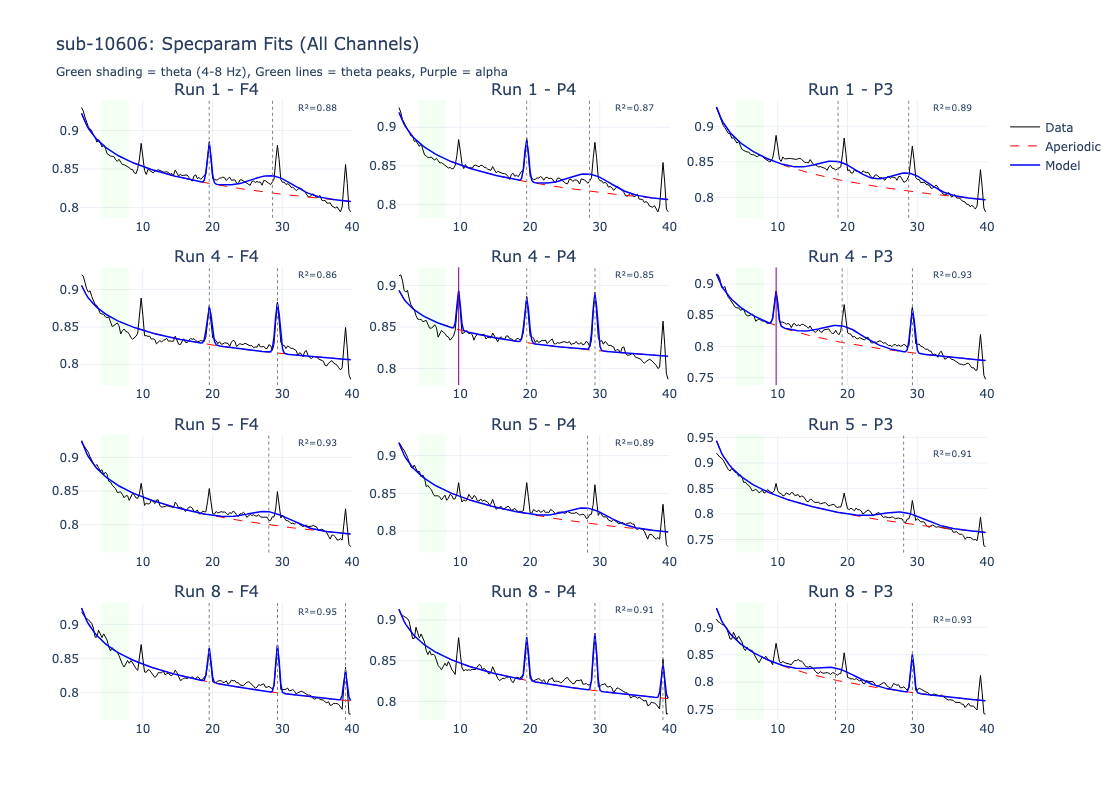

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/plots/specparam_multichannel_sub-10606_20260318.html


In [26]:
# =============================================================================
# 6b. Multi-Channel Specparam Diagnostic Plot
# =============================================================================

if 'specparam_results' in result and len(result['specparam_results']) > 0:
    # Get unique runs
    runs = sorted(set(r['run'] for r in result['specparam_results']))
    
    # Create subplot grid: rows = runs, cols = channels
    n_runs = len(runs)
    n_channels = len(EEG_CH_LABELS)
    
    fig = make_subplots(
        rows=n_runs, cols=n_channels,
        subplot_titles=[f'Run {r} - {ch}' for r in runs for ch in EEG_CH_LABELS],
        horizontal_spacing=0.05,
        vertical_spacing=0.08,
    )
    
    for row_idx, run_num in enumerate(runs):
        for col_idx, ch_label in enumerate(EEG_CH_LABELS):
            # Find the result for this run/channel
            matches = [r for r in result['specparam_results'] 
                      if r['run'] == run_num and r['channel'] == ch_label]
            
            if not matches:
                continue
            
            res = matches[0]
            components = res['components']
            
            if components is None:
                continue
            
            freqs = components['freqs']
            power = components['power_spectrum']
            ap_fit = components['aperiodic_fit']
            model_fit = components['modeled_spectrum']
            r2 = components['r_squared']
            peaks = components['peaks']
            
            # Plot data
            fig.add_trace(go.Scatter(
                x=freqs, y=power,
                mode='lines', line=dict(color='black', width=1),
                name='Data', showlegend=(row_idx==0 and col_idx==0),
            ), row=row_idx+1, col=col_idx+1)
            
            # Plot aperiodic fit
            fig.add_trace(go.Scatter(
                x=freqs, y=ap_fit,
                mode='lines', line=dict(color='red', width=1, dash='dash'),
                name='Aperiodic', showlegend=(row_idx==0 and col_idx==0),
            ), row=row_idx+1, col=col_idx+1)
            
            # Plot full model
            fig.add_trace(go.Scatter(
                x=freqs, y=model_fit,
                mode='lines', line=dict(color='blue', width=1.5),
                name='Model', showlegend=(row_idx==0 and col_idx==0),
            ), row=row_idx+1, col=col_idx+1)
            
            # Mark peaks
            if len(peaks) > 0:
                for peak in peaks:
                    cf = peak[0]
                    in_theta = 4 <= cf <= 8
                    in_alpha = 8 <= cf <= 13
                    
                    if in_theta:
                        color = 'green'
                        dash = 'solid'
                    elif in_alpha:
                        color = 'purple'
                        dash = 'solid'
                    else:
                        color = 'gray'
                        dash = 'dot'
                    
                    fig.add_vline(
                        x=cf, line=dict(color=color, width=1, dash=dash),
                        row=row_idx+1, col=col_idx+1
                    )
            
            # Add theta band shading
            fig.add_vrect(
                x0=4, x1=8, fillcolor='rgba(0,255,0,0.05)', line_width=0,
                row=row_idx+1, col=col_idx+1
            )
            
            # Add R² annotation
            r2_str = f'R²={r2:.2f}' if r2 else 'No fit'
            fig.add_annotation(
                x=35, y=max(power),
                text=r2_str,
                showarrow=False,
                font=dict(size=9),
                row=row_idx+1, col=col_idx+1,
            )
    
    fig.update_xaxes(range=[1, 40])
    fig.update_layout(
        height=200 * n_runs,
        width=300 * n_channels,
        template='plotly_white',
        title=f'sub-{SUBJECT_ID}: Specparam Fits (All Channels)<br>'
              f'<sub>Green shading = theta (4-8 Hz), Green lines = theta peaks, Purple = alpha</sub>',
        showlegend=True,
        legend=dict(x=1.02, y=0.98),
    )
    
    fig.show()
    
    # Save with descriptive name
    save_plot(fig, 'specparam_multichannel', subject_id=SUBJECT_ID, format='html')
else:
    print('No specparam results to plot.')

In [27]:
# =============================================================================
# 6c. Detailed Peak Summary Table
# =============================================================================

if 'specparam_results' in result and len(result['specparam_results']) > 0:
    print(f'\nDetailed Peak Summary for sub-{SUBJECT_ID}')
    print('=' * 90)
    print(f'{"Run":>4} {"Cond":>8} {"Ch":>4} {"R²":>6} {"Peaks":>30} {"Theta":>8} {"Alpha":>8}')
    print('-' * 90)
    
    for res in sorted(result['specparam_results'], key=lambda x: (x['run'], x['channel'])):
        peaks = res['all_peaks']
        if peaks is not None and len(peaks) > 0:
            peak_str = ', '.join([f'{p[0]:.1f}' for p in peaks])
        else:
            peak_str = 'None'
        
        r2 = res['r_squared']
        r2_str = f'{r2:.3f}' if r2 else 'N/A'
        
        itf_str = f'{res["itf"]:.1f}' if res['itf'] else '-'
        iaf_str = f'{res["iaf"]:.1f}' if res['iaf'] else '-'
        
        print(f'{res["run"]:>4} {res["condition"]:>8} {res["channel"]:>4} '
              f'{r2_str:>6} {peak_str:>30} {itf_str:>8} {iaf_str:>8}')


Detailed Peak Summary for sub-10606
 Run     Cond   Ch     R²                          Peaks    Theta    Alpha
------------------------------------------------------------------------------------------
   1 baseline   F4  0.882                     19.5, 28.6        -        -
   1 baseline   P3  0.887                     18.7, 28.8        -        -
   1 baseline   P4  0.866                     19.5, 28.5        -        -
   4     post   F4  0.858                     19.5, 29.3        -        -
   4     post   P3  0.928                9.8, 19.2, 29.3        -      9.8
   4     post   P4  0.845                9.8, 19.5, 29.3        -      9.8
   5 baseline   F4  0.929                           28.1        -        -
   5 baseline   P3  0.915                           28.1        -        -
   5 baseline   P4  0.895                           28.2        -        -
   8     post   F4  0.949               19.5, 29.3, 39.0        -        -
   8     post   P3  0.935                     1

---## 6. 6 Hz Timecourse DiagnosticsVisualize 6 Hz power across all runs for a single subject. Active runs show a sustained plateau; sham runs show brief ramp artifacts at the edges.### 6a. Group Diagnostic

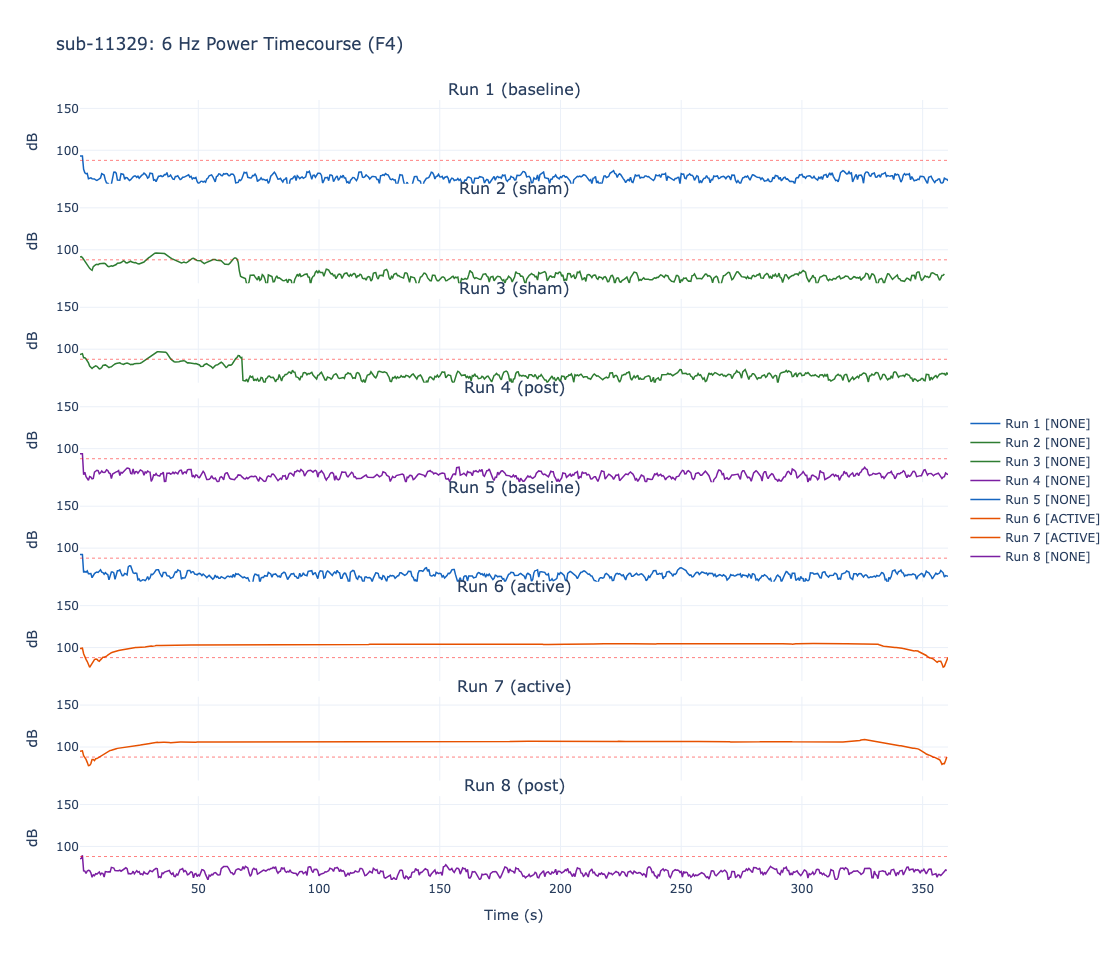

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/plots/6hz_timecourse_sub-11329_20260318.html


PosixPath('/Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/plots/6hz_timecourse_sub-11329_20260318.html')

In [29]:
PLOT_SUBJECT = '11329'

sub_info = SUBJECT_INFO[PLOT_SUBJECT]
run_files = discover_runs(EEG_DIR, PLOT_SUBJECT)
condition_map = RUN_CONDITIONS[sub_info['counterbalance']]

available_runs = sorted(run_files.keys())
n_runs = len(available_runs)

fig = make_subplots(
    rows=n_runs, cols=1, shared_xaxes=True, vertical_spacing=0.02,
    subplot_titles=[f'Run {r} ({condition_map.get(r, "?")})' for r in available_runs],
)

condition_colors = {
    'baseline': '#1565C0',
    'sham':     '#2E7D32',
    'active':   '#E65100',
    'post':     '#7B1FA2',
}

thresholds = STIM_THRESHOLDS['earclip' if sub_info['earclip'] else 'no_earclip']

for i, run_num in enumerate(available_runs):
    files = run_files[run_num]
    nic2 = load_nic2_run(files['easy'], files['info'], files['imp'])
    condition = condition_map.get(run_num, 'unknown')
    
    t_spec, power_db = compute_6hz_timecourse(nic2['eeg'][:, EEG_CH_IDX[0]])
    stim_class, stim_info = classify_stimulation(nic2['eeg'][:, EEG_CH_IDX[0]], sub_info['earclip'])
    # Note: this uses the single-run wrapper; batch processing uses classify_all_runs()
    
    color = condition_colors.get(condition, '#999999')
    
    fig.add_trace(go.Scatter(
        x=t_spec, y=power_db,
        mode='lines', line=dict(color=color, width=1.5),
        name=f'Run {run_num} [{stim_class}]',
    ), row=i+1, col=1)
    
    # Show threshold reference line (absolute floor for this hardware config)
    fig.add_hline(y=thresholds['active_middle_min_db'], 
                  line=dict(color='red', width=0.5, dash='dot'),
                  row=i+1, col=1)
    
    fig.update_yaxes(range=[60, 160], title_text='dB', row=i+1, col=1)

fig.update_xaxes(title_text='Time (s)', row=n_runs, col=1)
fig.update_layout(
    height=120 * n_runs, width=900,
    template='plotly_white',
    title=f'sub-{PLOT_SUBJECT}: 6 Hz Power Timecourse (F4)',
    showlegend=True,
    legend=dict(x=1.02, y=0.5),
)

fig.show()
save_plot(fig, '6hz_timecourse', subject_id=PLOT_SUBJECT, format='html')

### 6b. Single-Subject DiagnosticChange `PLOT_SUBJECT` above to inspect any subject.---## 7. Theta ReactivityCompute a robust theta reactivity metric from verified clean baseline runs. The quality audit output from §5 is used to exclude any baseline runs with detected problems.**Primary metric**: `theta_p95` — the 95th percentile of percent-change theta power.

In [31]:
def compute_theta_reactivity(audit_results, channel_idx=0, 
                             artifact_thresh_uv=150, skip_first_sec=10):
    """
    Compute theta reactivity metrics for all subjects using verified clean runs.
    
    Only analyzes baseline and post runs that passed the quality audit
    (i.e., stim_detected == 'NONE' and no protocol mismatches).
    
    Parameters
    ----------
    audit_results : list
        Output from batch processing (all_results from §5).
    channel_idx : int
        EEG channel index (0=F4, 1=P4, 2=P3).
    artifact_thresh_uv : float
        Artifact rejection threshold in microvolts.
    skip_first_sec : float
        Skip the first N seconds of recording (startup transient).
    """
    results = []
    
    for result in audit_results:
        if 'error' in result:
            continue
        
        subject_id = result['subject_id']
        has_earclip = result['has_earclip']
        
        # Get age
        age = get_subject_age(subject_id)
        
        # Only analyze baseline runs (1 and 5) that passed audit
        for run_num in [1, 5]:
            run_data = result.get('runs', {}).get(run_num, {})
            
            # Skip if run doesn't exist or had errors
            if not run_data or 'error' in run_data:
                continue
            
            # Skip if stimulation was detected (shouldn't happen for baselines,
            # but catches cases like 10951 Run 1)
            if run_data.get('stim_detected') not in ('NONE',):
                print(f'  Skipping sub-{subject_id} Run {run_num}: '
                      f'stim_detected={run_data.get("stim_detected")}')
                continue
            
            # Load and process EEG
            eeg_path = find_eeg_run(EEG_DIR, subject_id, run_num)
            if eeg_path is None:
                continue
            
            eeg_data = load_eeg_run(eeg_path)
            eeg_times = eeg_data['time_sec']
            eeg_data = preprocess_eeg_theta(eeg_data, has_earclip=has_earclip)
            
            raw_signal = eeg_data['eeg'][:, channel_idx].copy()
            theta_filtered = bandpass_filter(raw_signal, THETA_BAND, FS)
            analytic_signal = hilbert(theta_filtered)
            theta_power = np.abs(analytic_signal) ** 2
            
            artifact_mask = np.abs(raw_signal) > artifact_thresh_uv
            startup_mask = eeg_times < skip_first_sec
            combined_mask = artifact_mask | startup_mask
            
            window_samples = int(0.1 * FS)
            theta_power_smooth = np.convolve(theta_power, 
                                              np.ones(window_samples)/window_samples, mode='same')
            theta_power_smooth[combined_mask] = np.nan
            
            clean_mean = np.nanmean(theta_power_smooth)
            if clean_mean <= 0:
                continue
            
            theta_pct = (theta_power_smooth / clean_mean - 1) * 100
            clean_vals = theta_pct[~np.isnan(theta_pct)]
            if len(clean_vals) == 0:
                continue
            
            results.append({
                'subject_id': subject_id,
                'run': run_num,
                'age': age,
                'theta_median': np.median(clean_vals),
                'theta_p75': np.percentile(clean_vals, 75),
                'theta_p95': np.percentile(clean_vals, 95),
                'theta_p99': np.percentile(clean_vals, 99),
                'theta_max': np.max(clean_vals),
                'artifact_pct': 100 * combined_mask.sum() / len(combined_mask),
                'earclip': has_earclip
            })
    
    return pd.DataFrame(results)


theta_df = compute_theta_reactivity(all_results)
print("=== Theta Reactivity Metrics (F4) ===\n")
display(theta_df.round(1))


  Skipping sub-10951 Run 1: stim_detected=SHAM
=== Theta Reactivity Metrics (F4) ===



,subject_id,run,age,theta_median,theta_p75,theta_p95,theta_p99,theta_max,artifact_pct,earclip
0,10886,1,57,-31.3,36.2,201.1,360.5,780.9,2.8,False
1,10886,5,57,-33.1,34.8,197.0,397.9,1178.4,2.8,False
2,10998,5,23,-35.9,32.8,209.4,414.9,963.7,2.8,False
3,11773,1,56,-65.7,-5.4,362.7,682.7,1346.1,2.8,False
4,11773,5,56,-61.1,-10.0,327.2,941.5,2184.7,2.8,False
5,10656,1,24,-33.5,35.0,207.5,381.4,916.7,2.8,False
6,10656,5,24,-40.3,21.9,210.7,580.1,2354.1,2.8,False
7,10951,5,23,-49.2,20.0,263.8,561.8,1992.8,2.8,False
8,10418,1,71,-34.4,32.1,205.9,415.9,999.9,2.8,False
9,10418,5,71,-35.6,30.2,215.2,424.8,1604.5,2.8,False


---## 8. Theta Reactivity QC### 8a. Exclusion Criteria and Subject Averages

In [33]:
# Apply QC exclusion criteria
clean_runs = theta_df[
    (theta_df['artifact_pct'] < 10) &
    (theta_df['theta_p95'] > 0) &
    (theta_df['theta_p99'] < 1500)
].copy()

print(f"=== Clean Runs: {len(clean_runs)} of {len(theta_df)} ===")
display(clean_runs[['subject_id', 'run', 'age', 'theta_p95', 'theta_p99', 'artifact_pct']].round(1))

# Subject-level average from clean runs
clean_subject_avg = clean_runs.groupby('subject_id').agg({
    'theta_p95': 'mean',
    'theta_p75': 'mean',
    'age': 'first',
    'run': 'count'
}).rename(columns={'run': 'n_clean_runs'}).round(1)

clean_subject_avg = clean_subject_avg.sort_values('theta_p95', ascending=False)

print(f"\n=== Subject Averages (N={len(clean_subject_avg)}) ===")
display(clean_subject_avg)


=== Clean Runs: 25 of 26 ===


,subject_id,run,age,theta_p95,theta_p99,artifact_pct
0,10886,1,57,201.1,360.5,2.8
1,10886,5,57,197.0,397.9,2.8
2,10998,5,23,209.4,414.9,2.8
3,11773,1,56,362.7,682.7,2.8
4,11773,5,56,327.2,941.5,2.8
5,10656,1,24,207.5,381.4,2.8
6,10656,5,24,210.7,580.1,2.8
7,10951,5,23,263.8,561.8,2.8
8,10418,1,71,205.9,415.9,2.8
9,10418,5,71,215.2,424.8,2.8



=== Subject Averages (N=14) ===


,theta_p95,theta_p75,age,n_clean_runs
subject_id,,,,
11773,344.9,-7.7,56,2
11318,287.9,8.2,22,2
11329,268.9,12.0,25,2
10951,263.8,20.0,23,1
10369,243.2,-15.5,35,1
11628,226.3,32.4,56,2
11286,222.8,22.7,24,2
10866,219.6,28.9,74,2
10418,210.5,31.2,71,2


### 8b. Single-Subject Theta QC Visualization

In [35]:
def plot_run_theta_qc(subject_id, run_num, channel_idx=0, 
                      artifact_thresh_uv=150, skip_first_sec=10):
    """
    Create 4-panel QC visualization of continuous theta power.
    """
    from scipy.signal import hilbert
    
    eeg_path = find_eeg_run(EEG_DIR, subject_id, run_num)
    if eeg_path is None:
        print(f"EEG file not found for sub-{subject_id} Run {run_num}")
        return None
    
    eeg_data = load_eeg_run(eeg_path)
    eeg_times = eeg_data['time_sec']
    
    behav_dir = BEHAV_DIR / f'sub-{subject_id}'
    behav_path = get_latest_run_file(behav_dir, run_num)
    if behav_path is None:
        print(f"Behavioral file not found")
        return None
    
    behav_df = load_behavioral_run(behav_path)
    sub_info = SUBJECT_INFO.get(subject_id, {})
    has_earclip = sub_info.get('earclip', False)
    eeg_data = preprocess_eeg_theta(eeg_data, has_earclip=has_earclip)
    behav_df = align_timestamps(eeg_data, behav_df)
    feedback_times_eeg = behav_df['feedback_time_eeg']
    
    raw_signal = eeg_data['eeg'][:, channel_idx].copy()
    theta_filtered = bandpass_filter(raw_signal, THETA_BAND, FS)
    analytic_signal = hilbert(theta_filtered)
    theta_power = np.abs(analytic_signal) ** 2
    
    artifact_mask = np.abs(raw_signal) > artifact_thresh_uv
    startup_mask = eeg_times < skip_first_sec
    combined_mask = artifact_mask | startup_mask
    artifact_pct = 100 * combined_mask.sum() / len(combined_mask)
    
    window_samples = int(0.1 * FS)
    theta_power_smooth = np.convolve(theta_power, np.ones(window_samples)/window_samples, mode='same')
    theta_power_smooth_clean = theta_power_smooth.copy()
    theta_power_smooth_clean[combined_mask] = np.nan
    
    clean_mean = np.nanmean(theta_power_smooth_clean)
    theta_power_pct = (theta_power_smooth / clean_mean - 1) * 100
    theta_power_pct_clean = theta_power_pct.copy()
    theta_power_pct_clean[combined_mask] = np.nan
    
    print(f"Sub-{subject_id} Run {run_num}: {artifact_pct:.1f}% masked")
    
    # Downsample for plotting
    ds = 10
    times_ds = eeg_times[::ds]
    raw_ds = raw_signal[::ds]
    theta_ds = theta_power_pct_clean[::ds]
    
    # 4-panel figure
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                        row_heights=[0.15, 0.25, 0.30, 0.30],
                        vertical_spacing=0.03,
                        subplot_titles=['Feedback Events', 'Raw EEG (µV)', 
                                        'Theta Power (% change)', 'Zoomed View'])
    
    # Panel 1: Events
    for i, ft in enumerate(feedback_times_eeg):
        if ft > 0 and ft < eeg_times[-1]:
            reward_val = behav_df.iloc[i]['reward']
            is_reward = reward_val if isinstance(reward_val, bool) else str(reward_val).upper() == 'TRUE'
            fig.add_vline(x=ft, line_color=COLOR_GREEN if is_reward else COLOR_RED,
                          line_width=1, opacity=0.5, row=1, col=1)
    fig.add_vrect(x0=0, x1=skip_first_sec, fillcolor='gray', opacity=0.3, line_width=0, row=1, col=1)
    
    # Panel 2: Raw EEG
    fig.add_trace(go.Scatter(x=times_ds, y=raw_ds, mode='lines',
                              line=dict(color='black', width=0.5), showlegend=False), row=2, col=1)
    fig.add_hline(y=artifact_thresh_uv, line_dash='dash', line_color=COLOR_RED, opacity=0.5, row=2, col=1)
    fig.add_hline(y=-artifact_thresh_uv, line_dash='dash', line_color=COLOR_RED, opacity=0.5, row=2, col=1)
    
    # Panel 3: Full theta power
    fig.add_trace(go.Scatter(x=times_ds, y=theta_ds, mode='lines',
                              line=dict(color=COLOR_BLUE, width=1), showlegend=False), row=3, col=1)
    fig.add_hline(y=0, line_color='gray', line_dash='dash', opacity=0.5, row=3, col=1)
    
    # Add epoch windows
    epochs_shown = 0
    for ft in feedback_times_eeg:
        if ft - EPOCH_PRE > skip_first_sec and ft + EPOCH_POST < eeg_times[-1] and epochs_shown < 10:
            fig.add_vrect(x0=ft - EPOCH_PRE, x1=ft + EPOCH_POST,
                          fillcolor=COLOR_GOLD, opacity=0.2, line_width=0, row=3, col=1)
            fig.add_vline(x=ft, line_dash='dash', line_color=COLOR_RED, line_width=1, opacity=0.7, row=3, col=1)
            epochs_shown += 1
    
    # Panel 4: Zoomed view (60s window)
    zoom_start = skip_first_sec + 10
    zoom_end = zoom_start + 60
    zoom_mask = (times_ds >= zoom_start) & (times_ds <= zoom_end)
    
    fig.add_trace(go.Scatter(x=times_ds[zoom_mask], y=theta_ds[zoom_mask], mode='lines',
                              line=dict(color=COLOR_BLUE, width=1), showlegend=False), row=4, col=1)
    fig.add_hline(y=0, line_color='gray', line_dash='dash', opacity=0.5, row=4, col=1)
    
    for i, ft in enumerate(feedback_times_eeg):
        if zoom_start <= ft <= zoom_end:
            fig.add_vrect(x0=ft - EPOCH_PRE, x1=ft + EPOCH_POST,
                          fillcolor=COLOR_GOLD, opacity=0.2, line_width=0, row=4, col=1)
            fig.add_vline(x=ft, line_dash='dash', line_color=COLOR_RED, line_width=1.5, opacity=0.8, row=4, col=1)
    
    fig.update_xaxes(range=[zoom_start, zoom_end], row=4, col=1)
    
    ch_label = EEG_CH_LABELS[channel_idx]
    fig.update_layout(
        title=f'Sub-{subject_id} Run {run_num} — Theta QC ({ch_label})<br>'
              f'<sup>Artifact: {artifact_pct:.1f}% masked | Green=reward, Red=no-reward | Yellow=epoch windows</sup>',
        template=PLOTLY_TEMPLATE, font=dict(family='Arial'),
        height=800, width=1200, showlegend=False
    )
    
    fig.update_xaxes(title_text='Time (s)', row=4, col=1, showgrid=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig



# Plot QC for example subjects — pick the highest and lowest theta reactivity
if len(clean_subject_avg) >= 2:
    high_sub = clean_subject_avg.index[0]
    low_sub = clean_subject_avg.index[-1]
    
    print("=" * 70)
    print(f"HIGH THETA REACTIVITY SUBJECT (sub-{high_sub})")
    print("=" * 70)
    fig_high = plot_run_theta_qc(high_sub, 1)
    
    print("\n" + "=" * 70)
    print(f"LOW THETA REACTIVITY SUBJECT (sub-{low_sub})")
    print("=" * 70)
    fig_low = plot_run_theta_qc(low_sub, 1)


HIGH THETA REACTIVITY SUBJECT (sub-11773)


NameError: name 'align_timestamps' is not defined

### 8c. Individual Differences Bar Plot

In [ ]:
def plot_theta_reactivity_bar(clean_subject_avg):
    """
    Bar plot showing individual differences in theta reactivity.
    """
    df = clean_subject_avg.reset_index().sort_values('theta_p95', ascending=True)
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        y=df['subject_id'],
        x=df['theta_p95'],
        orientation='h',
        marker=dict(
            color=df['theta_p95'],
            colorscale=[[0, COLOR_BLUE], [1, COLOR_GOLD]],
            showscale=True,
            colorbar=dict(title='θ p95 (%)')
        ),
        text=df['theta_p95'].round(0).astype(int).astype(str) + '%',
        textposition='outside'
    ))
    
    fig.update_layout(
        title='Individual Differences in Theta Reactivity (F4)',
        xaxis_title='Theta p95 (% change from baseline)',
        yaxis_title='Subject',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        height=400,
        showlegend=False
    )
    
    fig.update_xaxes(showgrid=False, zeroline=True, zerolinecolor='gray', linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig



if len(clean_subject_avg) > 0:
    fig_bar = plot_theta_reactivity_bar(clean_subject_avg)
    if fig_bar:
        fig_bar.write_html(THETA_DIR / 'theta_reactivity_individual_differences.html')


---## 9. Test-Retest Reliability

In [ ]:
def compute_run_reliability(df):
    """
    Correlate theta metrics between Run 1 and Run 5.
    """
    run1 = df[df['run'] == 1].set_index('subject_id')
    run5 = df[df['run'] == 5].set_index('subject_id')
    
    common_subs = run1.index.intersection(run5.index)
    
    print(f"=== Test-Retest Reliability: Run 1 vs Run 5 ===")
    print(f"Subjects with both baseline runs: {len(common_subs)}")
    print(f"Subjects: {list(common_subs)}\n")
    
    if len(common_subs) < 3:
        print("Too few subjects for reliability analysis")
        return None, None
    
    metrics = ['theta_p75', 'theta_p95', 'theta_p99']
    reliability_results = []
    
    for metric in metrics:
        r1_vals = run1.loc[common_subs, metric].values
        r5_vals = run5.loc[common_subs, metric].values
        
        r, p = pearsonr(r1_vals, r5_vals)
        
        subject_means = (r1_vals + r5_vals) / 2
        ms_subjects = np.var(subject_means, ddof=1) * 2
        diffs = r1_vals - r5_vals
        ms_error = np.var(diffs, ddof=1) / 2
        icc = (ms_subjects - ms_error) / (ms_subjects + ms_error) if (ms_subjects + ms_error) > 0 else np.nan
        
        reliability_results.append({'metric': metric, 'r': r, 'p': p, 'ICC': icc, 'n': len(common_subs)})
        
        print(f"{metric}: Pearson r = {r:.3f}, p = {p:.3f}, ICC ≈ {icc:.3f}")
    
    # Create Plotly figure
    fig = make_subplots(rows=1, cols=3, subplot_titles=metrics, horizontal_spacing=0.08)
    
    for idx, metric in enumerate(metrics):
        r1_vals = run1.loc[common_subs, metric].values
        r5_vals = run5.loc[common_subs, metric].values
        r, p = pearsonr(r1_vals, r5_vals)
        
        fig.add_trace(go.Scatter(
            x=r1_vals, y=r5_vals, mode='markers+text',
            marker=dict(size=12, color=COLOR_BLUE, opacity=0.7, line=dict(width=1, color='black')),
            text=list(common_subs), textposition='top right', textfont=dict(size=9),
            showlegend=False
        ), row=1, col=idx+1)
        
        all_vals = np.concatenate([r1_vals, r5_vals])
        line_range = [all_vals.min() * 0.9, all_vals.max() * 1.1]
        fig.add_trace(go.Scatter(x=line_range, y=line_range, mode='lines',
                                  line=dict(dash='dash', color='gray', width=1), showlegend=False), row=1, col=idx+1)
        
        z = np.polyfit(r1_vals, r5_vals, 1)
        fig.add_trace(go.Scatter(x=np.sort(r1_vals), y=np.poly1d(z)(np.sort(r1_vals)), mode='lines',
                                  line=dict(color=COLOR_RED, width=2), showlegend=False), row=1, col=idx+1)
        
        fig.layout.annotations[idx].text = f'{metric}<br>r = {r:.2f}, p = {p:.3f}'
        fig.update_xaxes(title_text=f'Run 1', row=1, col=idx+1, showgrid=False, linecolor='black', linewidth=1)
        fig.update_yaxes(title_text=f'Run 5', row=1, col=idx+1, showgrid=False, linecolor='black', linewidth=1)
    
    fig.update_layout(title='Test-Retest Reliability: Baseline Runs', template=PLOTLY_TEMPLATE,
                      font=dict(family='Arial'), height=400, width=1000)
    fig.show()
    
    print("\n" + "="*60 + "\nINTERPRETATION\n" + "="*60)
    print("ICC: <0.40=Poor, 0.40-0.59=Fair, 0.60-0.74=Good, 0.75-1.00=Excellent")
    
    return pd.DataFrame(reliability_results), fig



reliability_df, fig_rel = compute_run_reliability(clean_runs)
if fig_rel:
    fig_rel.write_html(THETA_DIR / 'theta_reliability_run1_vs_run5.html')
    print(f"\nSaved: {THETA_DIR / 'theta_reliability_run1_vs_run5.html'}")


---## 10. Individual Differences: Theta Reactivity vs Age

In [ ]:
def plot_theta_vs_age(clean_subject_avg):
    """
    Scatter plot of theta reactivity (p95) vs age.
    """
    df = clean_subject_avg.reset_index().dropna(subset=['age', 'theta_p95'])
    
    if len(df) < 3:
        print("Not enough subjects with age data")
        return None
    
    # Compute correlation
    r, p = pearsonr(df['age'], df['theta_p95'])
    rho, p_spearman = spearmanr(df['age'], df['theta_p95'])
    
    print(f"=== Theta Reactivity vs Age ===")
    print(f"N = {len(df)} subjects")
    print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")
    print(f"Pearson r = {r:.3f}, p = {p:.3f}")
    print(f"Spearman ρ = {rho:.3f}, p = {p_spearman:.3f}")
    
    # Create scatter plot
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df['age'],
        y=df['theta_p95'],
        mode='markers+text',
        marker=dict(size=14, color=COLOR_BLUE, opacity=0.7, line=dict(width=1, color='black')),
        text=df['subject_id'],
        textposition='top right',
        textfont=dict(size=10),
        name='Subjects'
    ))
    
    # Add regression line
    z = np.polyfit(df['age'], df['theta_p95'], 1)
    x_line = np.linspace(df['age'].min() - 5, df['age'].max() + 5, 100)
    fig.add_trace(go.Scatter(
        x=x_line,
        y=np.poly1d(z)(x_line),
        mode='lines',
        line=dict(color=COLOR_RED, width=2, dash='dash'),
        name=f'Regression (r={r:.2f})'
    ))
    
    fig.update_layout(
        title=f'Theta Reactivity vs Age<br><sup>N={len(df)}, r={r:.2f}, p={p:.3f}</sup>',
        xaxis_title='Age (years)',
        yaxis_title='Theta Reactivity (p95, % change)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99),
        height=500,
        width=700
    )
    
    fig.update_xaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig, df



if len(clean_subject_avg) >= 3:
    fig_age_scatter, age_df = plot_theta_vs_age(clean_subject_avg)
    if fig_age_scatter:
        fig_age_scatter.write_html(THETA_DIR / 'theta_reactivity_vs_age_scatter.html')
else:
    age_df = None
    print("Not enough subjects for age analysis")


### Young vs Old Comparison

In [ ]:
def plot_young_vs_old(df, age_cutoff=55):
    """
    Compare theta reactivity between young (<55) and older (55+) adults.
    """
    if df is None or len(df) < 2:
        print("Not enough data")
        return None
    
    df = df.copy()
    df['age_group'] = df['age'].apply(lambda x: 'Young (<55)' if x < age_cutoff else 'Older (55+)')
    
    young = df[df['age_group'] == 'Young (<55)']['theta_p95']
    older = df[df['age_group'] == 'Older (55+)']['theta_p95']
    
    print(f"=== Young vs Older Adults (cutoff: {age_cutoff}) ===")
    print(f"Young (<{age_cutoff}): N={len(young)}, M={young.mean():.1f}%, SD={young.std():.1f}%")
    print(f"Older ({age_cutoff}+): N={len(older)}, M={older.mean():.1f}%, SD={older.std():.1f}%")
    
    if len(young) >= 2 and len(older) >= 2:
        t, p = ttest_ind(young, older)
        print(f"Independent t-test: t={t:.2f}, p={p:.3f}")
    else:
        print("Not enough subjects in each group for t-test")
    
    # Create grouped bar plot
    group_stats = df.groupby('age_group')['theta_p95'].agg(['mean', 'std', 'count']).reset_index()
    group_stats['sem'] = group_stats['std'] / np.sqrt(group_stats['count'])
    
    fig = go.Figure()
    
    colors = [COLOR_GOLD, COLOR_BLUE]
    
    for i, row in group_stats.iterrows():
        fig.add_trace(go.Bar(
            x=[row['age_group']],
            y=[row['mean']],
            error_y=dict(type='data', array=[row['sem']], visible=True),
            marker_color=colors[i],
            name=f"{row['age_group']} (n={int(row['count'])})",
            text=f"{row['mean']:.0f}%",
            textposition='outside'
        ))
    
    # Add individual points
    for i, grp in enumerate(['Young (<55)', 'Older (55+)']):
        grp_data = df[df['age_group'] == grp]
        fig.add_trace(go.Scatter(
            x=[grp] * len(grp_data),
            y=grp_data['theta_p95'],
            mode='markers',
            marker=dict(size=10, color='black', opacity=0.5),
            showlegend=False
        ))
    
    fig.update_layout(
        title=f'Theta Reactivity by Age Group<br><sup>Cutoff: {age_cutoff} years | Error bars: SEM</sup>',
        xaxis_title='Age Group',
        yaxis_title='Theta Reactivity (p95, % change)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        showlegend=True,
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99),
        height=500,
        width=500,
        bargap=0.3
    )
    
    fig.update_xaxes(showgrid=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=True, zerolinecolor='gray', linecolor='black', linewidth=1)
    
    fig.show()
    return fig



if age_df is not None and len(age_df) >= 4:
    fig_age_groups = plot_young_vs_old(age_df, age_cutoff=55)
    if fig_age_groups:
        fig_age_groups.write_html(THETA_DIR / 'theta_reactivity_young_vs_old.html')


---## 11. ERSP Analysis (Exploratory)Epoch-locked theta ERSP from baseline runs. This section depends on the heuristic timestamp alignment and should be interpreted with the caveat that precise timing claims cannot be made without hardware synchronization.

In [ ]:
def align_timestamps(eeg_data, behav_data):
    """
    Align behavioral feedback times to EEG recording time using heuristic approach.
    """
    behav_data = behav_data.copy()
    
    eeg_duration = eeg_data['duration_sec']
    behav_span = behav_data['feedback_time_relative'].max()
    
    margin_start = EPOCH_PRE + 0.5
    margin_end = EPOCH_POST + 0.5
    
    if behav_span > eeg_duration:
        raise ValueError(f'Behavioral data ({behav_span:.1f}s) exceeds EEG duration ({eeg_duration:.1f}s)')
    
    estimated_first_feedback = 20.0
    
    last_feedback_time = estimated_first_feedback + behav_span
    if last_feedback_time > eeg_duration - margin_end:
        estimated_first_feedback = eeg_duration - margin_end - behav_span
    
    if estimated_first_feedback < margin_start:
        available_slack = eeg_duration - behav_span - margin_start - margin_end
        if available_slack < 0:
            estimated_first_feedback = EPOCH_PRE + 0.1
        else:
            estimated_first_feedback = margin_start
    
    behav_data['feedback_time_eeg'] = behav_data['feedback_time_relative'] + estimated_first_feedback
    
    behav_data.attrs['estimated_first_feedback'] = estimated_first_feedback
    behav_data.attrs['offset_sec'] = estimated_first_feedback
    behav_data.attrs['behav_span'] = behav_span
    behav_data.attrs['alignment_method'] = 'heuristic'
    
    return behav_data


def align_response_timestamps(eeg_data, behav_data):
    """
    Align response times to EEG recording for response-locked analysis.
    """
    behav_data = behav_data.copy()
    
    eeg_duration = eeg_data['duration_sec']
    response_span = behav_data['response_time_relative'].max()
    feedback_span = behav_data['feedback_time_relative'].max()
    resp_to_fb_delay = behav_data.attrs.get('response_to_feedback_delay', 2.5)
    
    margin_start = EPOCH_PRE + 0.5
    margin_end = EPOCH_POST + 0.5
    total_span = feedback_span + resp_to_fb_delay
    
    estimated_first_response = 10.0
    
    if estimated_first_response + total_span > eeg_duration - margin_end:
        estimated_first_response = eeg_duration - margin_end - total_span
    
    if estimated_first_response < margin_start:
        estimated_first_response = margin_start
    
    behav_data['response_time_eeg'] = behav_data['response_time_relative'] + estimated_first_response
    behav_data['feedback_time_eeg'] = behav_data['feedback_time_relative'] + estimated_first_response + resp_to_fb_delay
    
    behav_data.attrs['estimated_first_response'] = estimated_first_response
    behav_data.attrs['response_span'] = response_span
    
    return behav_data


def validate_alignment(eeg_data, behav_data):
    """Check whether behavioral events fall within EEG recording window."""
    eeg_duration = eeg_data['duration_sec']
    feedback_times = behav_data['feedback_time_eeg'].values
    
    min_time = feedback_times.min() - EPOCH_PRE
    max_time = feedback_times.max() + EPOCH_POST
    
    within_bounds = (min_time >= 0) and (max_time <= eeg_duration)
    n_valid = np.sum((feedback_times - EPOCH_PRE >= 0) & 
                     (feedback_times + EPOCH_POST <= eeg_duration))
    
    return {
        'eeg_duration_sec': eeg_duration,
        'first_feedback_sec': feedback_times.min(),
        'last_feedback_sec': feedback_times.max(),
        'behav_span_sec': behav_data.attrs.get('behav_span', feedback_times.max() - feedback_times.min()),
        'offset_sec': behav_data.attrs.get('offset_sec', np.nan),
        'alignment_method': behav_data.attrs.get('alignment_method', 'unknown'),
        'within_bounds': within_bounds,
        'n_trials': len(feedback_times),
        'n_valid_epochs': n_valid
    }


print('Timestamp alignment functions defined.')

In [ ]:
def extract_epochs(eeg_data, event_times, pre_sec=EPOCH_PRE, post_sec=EPOCH_POST, 
                   reject_artifacts=True):
    """
    Extract epochs time-locked to events.
    """
    eeg = eeg_data['eeg']
    fs = eeg_data['fs']
    artifact_mask = eeg_data.get('artifact_mask', np.zeros(len(eeg), dtype=bool))
    
    n_pre = int(pre_sec * fs)
    n_post = int(post_sec * fs)
    n_samples = n_pre + n_post
    n_channels = eeg.shape[1]
    
    times = np.linspace(-pre_sec, post_sec, n_samples, endpoint=False)
    
    epochs = []
    valid_idx = []
    reject_idx = []
    
    for i, t in enumerate(event_times):
        center_sample = int(t * fs)
        start_sample = center_sample - n_pre
        end_sample = center_sample + n_post
        
        if start_sample < 0 or end_sample > len(eeg):
            reject_idx.append(i)
            continue
        
        segment = eeg[start_sample:end_sample, :]
        
        if reject_artifacts and np.any(artifact_mask[start_sample:end_sample]):
            reject_idx.append(i)
            continue
        
        epochs.append(segment)
        valid_idx.append(i)
    
    if len(epochs) == 0:
        return {
            'epochs': np.zeros((0, n_samples, n_channels)),
            'times': times,
            'valid_idx': np.array([], dtype=int),
            'reject_idx': np.array(reject_idx, dtype=int),
            'n_valid': 0,
            'n_rejected': len(reject_idx)
        }
    
    return {
        'epochs': np.stack(epochs, axis=0),
        'times': times,
        'valid_idx': np.array(valid_idx, dtype=int),
        'reject_idx': np.array(reject_idx, dtype=int),
        'n_valid': len(epochs),
        'n_rejected': len(reject_idx)
    }


print('Epoching functions defined.')

In [ ]:
def compute_band_power_timecourse(epochs, times, band=THETA_BAND, fs=FS):
    """
    Compute instantaneous band power for each epoch using Hilbert transform.
    """
    n_epochs, n_samples, n_channels = epochs.shape
    power = np.zeros_like(epochs)
    
    for ch in range(n_channels):
        for ep in range(n_epochs):
            filtered = bandpass_filter(epochs[ep, :, ch], band, fs)
            analytic = signal.hilbert(filtered)
            envelope = np.abs(analytic)
            power[ep, :, ch] = envelope ** 2
    
    return power


def compute_ersp(epochs, times, band=THETA_BAND, baseline_win=BASELINE_WIN, fs=FS):
    """
    Compute Event-Related Spectral Perturbation (ERSP).
    ERSP = (power - baseline_power) / baseline_power * 100
    """
    power = compute_band_power_timecourse(epochs, times, band, fs)
    
    baseline_mask = (times >= baseline_win[0]) & (times < baseline_win[1])
    baseline_power = power[:, baseline_mask, :].mean(axis=1, keepdims=True)
    baseline_power = np.maximum(baseline_power, 1e-10)
    
    ersp_epochs = (power - baseline_power) / baseline_power * 100
    ersp = ersp_epochs.mean(axis=0)
    
    return {
        'ersp': ersp,
        'power': power,
        'times': times
    }


print('Theta power analysis functions defined.')

In [ ]:
def analyze_subject_run(subject_id, run_num, verbose=True):
    """
    Full analysis pipeline for a single subject and run.
    """
    if verbose:
        print(f'\n--- Sub-{subject_id}, Run {run_num} ---')
    
    sub_info = SUBJECT_INFO.get(subject_id, {})
    has_earclip = sub_info.get('earclip', False)
    
    # --- Load EEG ---
    eeg_path = find_eeg_run(EEG_DIR, subject_id, run_num)
    if eeg_path is None:
        if verbose:
            print(f'  EEG file not found')
        return None
    
    eeg_data = load_eeg_run(eeg_path)
    if verbose:
        print(f'  EEG loaded: {eeg_data["duration_sec"]:.1f}s')
    
    # --- Load behavioral ---
    behav_dir = BEHAV_DIR / f'sub-{subject_id}'
    behav_path = get_latest_run_file(behav_dir, run_num)
    if behav_path is None:
        if verbose:
            print(f'  Behavioral file not found')
        return None
    
    behav_data = load_behavioral_run(behav_path)
    if verbose:
        print(f'  Behavioral loaded: {len(behav_data)} trials')
    
    # --- Preprocess EEG ---
    eeg_data = preprocess_eeg_theta(eeg_data, has_earclip=has_earclip)
    if verbose:
        print(f'  Artifacts: {eeg_data["artifact_pct"]:.1f}%')
    
    # --- Align timestamps ---
    behav_data = align_timestamps(eeg_data, behav_data)
    
    # --- Validate alignment ---
    alignment = validate_alignment(eeg_data, behav_data)
    if verbose:
        print(f'  Alignment method: {alignment["alignment_method"]}')
        print(f'  Behavioral span: {alignment["behav_span_sec"]:.1f}s, EEG duration: {alignment["eeg_duration_sec"]:.1f}s')
        print(f'  Estimated offset: {alignment["offset_sec"]:.1f}s (first feedback in EEG time)')
        print(f'  Feedback range: {alignment["first_feedback_sec"]:.1f}s - {alignment["last_feedback_sec"]:.1f}s')
        print(f'  Within bounds: {alignment["within_bounds"]}')
    
    if not alignment['within_bounds']:
        if verbose:
            print('  WARNING: Events outside EEG recording window!')
        return None
    
    # --- Extract epochs ---
    feedback_times = behav_data['feedback_time_eeg'].values
    epoch_result = extract_epochs(eeg_data, feedback_times)
    
    if epoch_result['n_valid'] == 0:
        if verbose:
            print('  No valid epochs!')
        return None
    
    if verbose:
        print(f'  Epochs: {epoch_result["n_valid"]} valid, {epoch_result["n_rejected"]} rejected')
    
    # --- Compute theta ERSP ---
    epochs = epoch_result['epochs']
    times = epoch_result['times']
    valid_idx = epoch_result['valid_idx']
    
    ersp_result = compute_ersp(epochs, times, band=THETA_BAND)
    
    # --- Split by reward/no-reward ---
    reward_col = behav_data.iloc[valid_idx]['reward']
    if reward_col.dtype == bool:
        reward_mask = reward_col.values
    else:
        reward_mask = reward_col.astype(str).str.upper() == 'TRUE'
        reward_mask = reward_mask.values
    
    n_reward = reward_mask.sum()
    n_no_reward = (~reward_mask).sum()
    
    ersp_reward = None
    ersp_no_reward = None
    
    if n_reward > 0:
        reward_epochs = epochs[reward_mask]
        ersp_reward = compute_ersp(reward_epochs, times, band=THETA_BAND)['ersp']
    
    if n_no_reward > 0:
        no_reward_epochs = epochs[~reward_mask]
        ersp_no_reward = compute_ersp(no_reward_epochs, times, band=THETA_BAND)['ersp']
    
    if verbose:
        print(f'  Reward trials: {n_reward}, No-reward trials: {n_no_reward}')
    
    # Get age
    age = None
    if 'age' in behav_data.columns:
        age = behav_data['age'].iloc[0]
    
    return {
        'subject_id': subject_id,
        'run_num': run_num,
        'has_earclip': has_earclip,
        'age': age,
        'n_trials': len(behav_data),
        'n_valid_epochs': epoch_result['n_valid'],
        'n_rejected': epoch_result['n_rejected'],
        'n_reward': n_reward,
        'n_no_reward': n_no_reward,
        'times': times,
        'ersp_all': ersp_result['ersp'],
        'ersp_reward': ersp_reward,
        'ersp_no_reward': ersp_no_reward,
        'alignment': alignment,
        'artifact_pct': eeg_data['artifact_pct']
    }


print('Single-subject pipeline defined.')

### 11a. Run ERSP on Baseline Runs

In [ ]:
# Analyze baseline runs (1 and 5) for all subjects
baseline_runs = [1, 5]
ersp_results = []

for subject_id in SUBJECT_INFO.keys():
    for run_num in baseline_runs:
        result = analyze_subject_run(subject_id, run_num, verbose=True)
        if result:
            ersp_results.append(result)

print(f'\n=== ERSP Summary ===')
print(f'Successfully analyzed: {len(ersp_results)} runs')
print(f'Subjects with data: {len(set(r["subject_id"] for r in ersp_results))}')


### 11b. Group Average ERSP

In [ ]:
def plot_group_ersp(results, channel_idx=0):
    """
    Plot group-average task-related theta ERSP using Plotly.
    """
    if len(results) == 0:
        print('No results to plot')
        return None
    
    ch_label = EEG_CH_LABELS[channel_idx]
    times = results[0]['times']
    
    all_ersp = np.stack([r['ersp_all'][:, channel_idx] for r in results])
    mean_ersp = all_ersp.mean(axis=0)
    sem_ersp = all_ersp.std(axis=0) / np.sqrt(len(results))
    
    fig = go.Figure()
    
    # SEM band
    fig.add_trace(go.Scatter(
        x=np.concatenate([times, times[::-1]]),
        y=np.concatenate([mean_ersp + sem_ersp, (mean_ersp - sem_ersp)[::-1]]),
        fill='toself',
        fillcolor='rgba(21, 101, 192, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='±SEM',
        showlegend=True
    ))
    
    # Mean line
    fig.add_trace(go.Scatter(
        x=times,
        y=mean_ersp,
        mode='lines',
        name='Mean',
        line=dict(color=COLOR_BLUE, width=2)
    ))
    
    fig.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.5)
    fig.add_hline(y=0, line_color='gray', opacity=0.5)
    
    n_subjects = len(set(r['subject_id'] for r in results))
    fig.update_layout(
        title=f'Group Average Task-Related Theta ({ch_label})<br><sup>N = {len(results)} runs from {n_subjects} subjects</sup>',
        xaxis_title='Time relative to feedback (s)',
        yaxis_title='Theta Power (% change from baseline)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        showlegend=True,
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99)
    )
    
    fig.update_xaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig



if ersp_results:
    fig_group = plot_group_ersp(ersp_results, channel_idx=0)
    if fig_group:
        fig_group.write_html(THETA_DIR / 'theta_ersp_group_average_F4.html')


### 11c. Reward vs No-Reward

In [ ]:
def plot_reward_comparison(results, channel_idx=0):
    """
    Plot group-average theta ERSP split by reward outcome.
    """
    if len(results) == 0:
        print('No results to plot')
        return None
    
    ch_label = EEG_CH_LABELS[channel_idx]
    times = results[0]['times']
    
    # Collect reward and no-reward ERSPs
    reward_ersps = [r['ersp_reward'][:, channel_idx] for r in results if r['ersp_reward'] is not None]
    no_reward_ersps = [r['ersp_no_reward'][:, channel_idx] for r in results if r['ersp_no_reward'] is not None]
    
    fig = go.Figure()
    
    if reward_ersps:
        reward_mean = np.stack(reward_ersps).mean(axis=0)
        reward_sem = np.stack(reward_ersps).std(axis=0) / np.sqrt(len(reward_ersps))
        
        fig.add_trace(go.Scatter(
            x=np.concatenate([times, times[::-1]]),
            y=np.concatenate([reward_mean + reward_sem, (reward_mean - reward_sem)[::-1]]),
            fill='toself', fillcolor='rgba(46, 125, 50, 0.2)',
            line=dict(color='rgba(255,255,255,0)'), showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=times, y=reward_mean, mode='lines',
            name=f'Reward (n={len(reward_ersps)})',
            line=dict(color=COLOR_GREEN, width=2)
        ))
    
    if no_reward_ersps:
        no_reward_mean = np.stack(no_reward_ersps).mean(axis=0)
        no_reward_sem = np.stack(no_reward_ersps).std(axis=0) / np.sqrt(len(no_reward_ersps))
        
        fig.add_trace(go.Scatter(
            x=np.concatenate([times, times[::-1]]),
            y=np.concatenate([no_reward_mean + no_reward_sem, (no_reward_mean - no_reward_sem)[::-1]]),
            fill='toself', fillcolor='rgba(198, 40, 40, 0.2)',
            line=dict(color='rgba(255,255,255,0)'), showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=times, y=no_reward_mean, mode='lines',
            name=f'No Reward (n={len(no_reward_ersps)})',
            line=dict(color=COLOR_RED, width=2)
        ))
    
    fig.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.5)
    fig.add_hline(y=0, line_color='gray', opacity=0.5)
    
    fig.update_layout(
        title=f'Reward vs No-Reward Theta ({ch_label})',
        xaxis_title='Time relative to feedback (s)',
        yaxis_title='Theta Power (% change from baseline)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99)
    )
    
    fig.update_xaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig



if ersp_results:
    fig_reward = plot_reward_comparison(ersp_results, channel_idx=0)
    if fig_reward:
        fig_reward.write_html(THETA_DIR / 'theta_ersp_reward_vs_noreward_F4.html')


### 11d. ERSP Summary Statistics

In [ ]:
def compute_summary_stats(results):
    """
    Compute summary statistics for each subject/run.
    """
    rows = []
    
    for r in results:
        times = r['times']
        post_mask = (times >= 0) & (times < 0.5)  # 0-500ms post-feedback
        
        for ch_idx, ch_label in enumerate(EEG_CH_LABELS):
            ersp = r['ersp_all'][:, ch_idx]
            ersp_post = ersp[post_mask]
            
            row = {
                'subject_id': r['subject_id'],
                'run': r['run_num'],
                'channel': ch_label,
                'age': r.get('age'),
                'has_earclip': r['has_earclip'],
                'n_trials': r['n_trials'],
                'n_valid_epochs': r['n_valid_epochs'],
                'n_reward': r['n_reward'],
                'n_no_reward': r['n_no_reward'],
                'theta_post_mean': ersp_post.mean(),
                'theta_post_max': ersp_post.max(),
                'theta_post_peak_latency_ms': times[post_mask][np.argmax(ersp_post)] * 1000
            }
            
            # Reward difference
            if r['ersp_reward'] is not None and r['ersp_no_reward'] is not None:
                rew_post = r['ersp_reward'][post_mask, ch_idx].mean()
                norew_post = r['ersp_no_reward'][post_mask, ch_idx].mean()
                row['theta_reward_mean'] = rew_post
                row['theta_noreward_mean'] = norew_post
                row['theta_reward_diff'] = norew_post - rew_post  # FRN-like: larger for no-reward
            
            rows.append(row)
    
    return pd.DataFrame(rows)



if len(ersp_results) > 0:
    ersp_summary_df = compute_summary_stats(ersp_results)
    ersp_output_path = THETA_DIR / 'feedback_theta_summary.csv'
    ersp_summary_df.to_csv(ersp_output_path, index=False)
    print(f'ERSP summary saved to: {ersp_output_path}')
    display(ersp_summary_df)


---## 12. Export Results

In [ ]:
# Subject-level audit summary
audit_path = OUTPUT_DIR / 'group_eeg_summary_combined.csv'
summary_df.to_csv(audit_path, index=False)
print(f'Saved audit summary: {audit_path}')

# Detected peaks
if len(peaks_df) > 0:
    peaks_path = OUTPUT_DIR / 'all_detected_peaks_combined.csv'
    peaks_df.to_csv(peaks_path, index=False)
    print(f'Saved peaks: {peaks_path}')

# Run-level details
run_rows = []
for result in all_results:
    if 'runs' not in result:
        continue
    for run_num, run_data in result['runs'].items():
        if isinstance(run_data, dict) and 'error' not in run_data:
            row = {'subject_id': result['subject_id'], 'run': run_num}
            row.update({k: v for k, v in run_data.items() 
                       if not isinstance(v, (np.ndarray, dict))})
            run_rows.append(row)

if run_rows:
    run_df = pd.DataFrame(run_rows)
    run_path = OUTPUT_DIR / 'run_level_details_combined.csv'
    run_df.to_csv(run_path, index=False)
    print(f'Saved run details: {run_path}')

# Theta reactivity
if len(theta_df) > 0:
    theta_path = THETA_DIR / 'theta_reactivity_combined.csv'
    theta_df.to_csv(theta_path, index=False)
    print(f'Saved theta reactivity: {theta_path}')

# Clean subject averages
if len(clean_subject_avg) > 0:
    avg_path = THETA_DIR / 'theta_reactivity_subject_avg_combined.csv'
    clean_subject_avg.to_csv(avg_path)
    print(f'Saved subject averages: {avg_path}')

print('\nAll exports complete.')


---## 13. Notes and Limitations### Methodological Notes1. **Timestamp alignment**: Without hardware synchronization (LSL markers), we use heuristic alignment. Sensitivity analysis confirms individual differences are robust to ±1s alignment shifts.2. **Task-related vs feedback-locked**: Theta metrics are described as "task-related" throughout. The ERSP analysis in §11 is exploratory.3. **Earclip reference**: Subjects with CMS/DRL earclip have hardware referencing; subjects without use software average re-referencing across 3 EEG channels.4. **Stimulation detection**: v5.2 uses cross-run adaptive classification (median + IQR) with an elevation override for unambiguous cases. This replaces the absolute-threshold approach that failed for earclip subjects.5. **Theta reactivity gating**: The theta reactivity pipeline (§7) only analyzes runs verified as NONE by the quality audit. This excludes runs with detected stimulation artifacts or protocol mismatches.